# MEMTO Reimplementation — Preprocessing & Exploratory Data Analysis
## NASA MSL & SMAP Telemetry Anomaly Detection Dataset

---

| Item | Detail |
|---|---|
| **Project Component** | Preprocessing & EDA (40% of total grade) |
| **Datasets** | MSL (Mars Science Laboratory) · SMAP (Soil Moisture Active Passive) |
| **Model** | MEMTO — Memory-augmented Transformer for time-series anomaly detection |
| **Reference** | *MEMTO: Memory-Guided Transformer for Multivariate Time Series Anomaly Detection* (NeurIPS 2023) |

---

## Table of Contents
1. [Imports & Configuration](#1)
2. [Dataset Overview & File Structure](#2)
3. [Load Labeled Anomalies CSV](#3)
4. [Load Train / Test `.npy` Files](#4)
5. [Shape & Basic Statistics Summary](#5)
6. [Data Quality Checks](#6)
7. [Dataset-Level EDA — Lengths & Feature Dimensions](#7)
8. [Class Imbalance Analysis](#8)
9. [Anomaly Sequence & Duration Analysis](#9)
10. [Anomaly vs Normal Segment Statistics](#10)
11. [MSL vs SMAP Inter-Dataset Comparison](#11)
12. [Time-Series Visualization with Anomaly Overlays](#12)
13. [Feature Value Distributions](#13)
14. [Feature Correlation Heatmap](#14)
15. [Autocorrelation (ACF) Analysis — Window Size Justification](#15)
16. [Rolling Statistics & Non-Stationarity](#16)
17. [Stationarity Test (ADF)](#17)
18. [Normalization — Justification & Before/After](#18)
19. [Outlier Analysis — MinMax vs StandardScaler](#19)
20. [Sliding Window Design & Memory-Error Fix](#20)
21. [Window Generation (stride=10 to prevent MemoryError)](#21)
22. [Train / Validation Split](#22)
23. [Anomaly Label Generation](#23)
24. [Final Preprocessing Summary](#24)
25. [Save Preprocessed Data](#25)


<a id='1'></a>
## 1. Imports & Configuration

In [1]:
import os, ast, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy import stats
from collections import defaultdict

warnings.filterwarnings('ignore')

# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'font.family'       : 'DejaVu Sans',
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
})

PALETTE = {
    'MSL'     : '#4C72B0',
    'SMAP'    : '#DD8452',
    'anomaly' : '#C44E52',
    'normal'  : '#55A868',
    'val'     : '#8172B2',
    'neutral' : '#8C8C8C',
}

print("✅ All imports successful.")
print(f"   NumPy   : {np.__version__}")
print(f"   Pandas  : {pd.__version__}")


✅ All imports successful.
   NumPy   : 2.4.2
   Pandas  : 3.0.1


<a id='2'></a>
## 2. Dataset Overview & File Structure

### About the Datasets

**MSL (Mars Science Laboratory)** and **SMAP (Soil Moisture Active Passive)** are two NASA telemetry
datasets widely used as benchmarks for multivariate time-series anomaly detection.

| Property | MSL | SMAP |
|---|---|---|
| Source | Mars rover telemetry | Earth satellite telemetry |
| Feature type | Multivariate (≈25 features) | Mostly univariate (1 feature) |
| Anomaly type | Point & contextual | Point & contextual |
| Split | Pre-split train/test .npy files | Pre-split train/test .npy files |

### Expected Directory Structure
```
dataset_root/
├── labeled_anomalies.csv     ← anomaly segment indices per channel
├── train/
│   ├── M-1.npy              ← MSL channels (shape: T × F)
│   ├── P-1.npy              ← SMAP channels
│   └── ...
└── test/
    ├── M-1.npy
    ├── P-1.npy
    └── ...
```

> **Set `DATASET_ROOT` below to your local dataset path before running.**


In [3]:
# ── ⚠️  UPDATE THIS PATH ──────────────────────────────────────────────────────
DATASET_ROOT = "./dataset"
# ─────────────────────────────────────────────────────────────────────────────

TRAIN_DIR  = os.path.join(DATASET_ROOT, "data/train")
TEST_DIR   = os.path.join(DATASET_ROOT, "data/test")
LABELS_CSV = os.path.join(DATASET_ROOT, "labeled_anomalies.csv")

print("Checking paths:")
for p in [DATASET_ROOT, TRAIN_DIR, TEST_DIR, LABELS_CSV]:
    status = "✅ Found" if os.path.exists(p) else "❌ NOT FOUND — update DATASET_ROOT"
    print(f"  {status}:  {p}")


Checking paths:
  ✅ Found:  ./dataset
  ✅ Found:  ./dataset\data/train
  ✅ Found:  ./dataset\data/test
  ✅ Found:  ./dataset\labeled_anomalies.csv


<a id='3'></a>
## 3. Load Labeled Anomalies CSV

In [4]:
labels_df = pd.read_csv(LABELS_CSV)
print(f"Shape   : {labels_df.shape}")
print(f"Columns : {list(labels_df.columns)}")
print(f"Spacecraft values: {labels_df['spacecraft'].unique()}")
labels_df.head(10)


Shape   : (82, 5)
Columns : ['chan_id', 'spacecraft', 'anomaly_sequences', 'class', 'num_values']
Spacecraft values: <ArrowStringArray>
['SMAP', 'MSL']
Length: 2, dtype: str


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307
5,E-4,SMAP,"[[5450, 8261]]",[point],8354
6,E-5,SMAP,"[[5600, 5920]]",[point],8294
7,E-6,SMAP,"[[5610, 5675]]",[point],8300
8,E-7,SMAP,"[[5394, 5674]]",[point],8310
9,E-8,SMAP,"[[5400, 6022]]",[point],8532


In [5]:
msl_labels  = labels_df[labels_df['spacecraft'] == 'MSL'].reset_index(drop=True)
smap_labels = labels_df[labels_df['spacecraft'] == 'SMAP'].reset_index(drop=True)

print(f"MSL  channels : {len(msl_labels):>4d}")
print(f"SMAP channels : {len(smap_labels):>4d}")
print(f"Total         : {len(labels_df):>4d}")
print()
print("Sample MSL entries:")
display(msl_labels[['chan_id', 'anomaly_sequences']].head(4))
print("Sample SMAP entries:")
display(smap_labels[['chan_id', 'anomaly_sequences']].head(4))


MSL  channels :   27
SMAP channels :   55
Total         :   82

Sample MSL entries:


,chan_id,anomaly_sequences
0,M-6,"[[1850, 2030]]"
1,M-1,"[[1110, 2250]]"
2,M-2,"[[1110, 2250]]"
3,S-2,"[[900, 910]]"


Sample SMAP entries:


,chan_id,anomaly_sequences
0,P-1,"[[2149, 2349], [4536, 4844], [3539, 3779]]"
1,S-1,"[[5300, 5747]]"
2,E-1,"[[5000, 5030], [5610, 6086]]"
3,E-2,"[[5598, 6995]]"


<a id='4'></a>
## 4. Load Train / Test `.npy` Files

In [6]:
def load_split(split_dir, label_df):
    """Load all .npy files listed in label_df from split_dir."""
    data, missing = {}, []
    for _, row in label_df.iterrows():
        chan  = row['chan_id']
        fpath = os.path.join(split_dir, f"{chan}.npy")
        if os.path.exists(fpath):
            data[chan] = np.load(fpath)
        else:
            missing.append(chan)
    if missing:
        print(f"  ⚠️  Missing files: {missing}")
    return data

msl_train  = load_split(TRAIN_DIR, msl_labels)
msl_test   = load_split(TEST_DIR,  msl_labels)
smap_train = load_split(TRAIN_DIR, smap_labels)
smap_test  = load_split(TEST_DIR,  smap_labels)

print(f"MSL  — train: {len(msl_train)} channels, test: {len(msl_test)} channels")
print(f"SMAP — train: {len(smap_train)} channels, test: {len(smap_test)} channels")

# Quick peek at array shapes
print("\nSample array shapes:")
for ds_name, ds in [("MSL train",  msl_train), ("MSL test",   msl_test),
                    ("SMAP train", smap_train), ("SMAP test",  smap_test)]:
    chan = list(ds.keys())[0]
    print(f"  {ds_name} [{chan}]: {ds[chan].shape}  dtype={ds[chan].dtype}")


MSL  — train: 27 channels, test: 27 channels
SMAP — train: 54 channels, test: 54 channels

Sample array shapes:
  MSL train [M-6]: (1565, 55)  dtype=float64
  MSL test [M-6]: (2049, 55)  dtype=float64
  SMAP train [P-1]: (2872, 25)  dtype=float64
  SMAP test [P-1]: (8505, 25)  dtype=float64


<a id='5'></a>
## 5. Shape & Basic Statistics Summary

In [7]:
def summarize_dataset(train_dict, test_dict, name):
    rows = []
    for chan in train_dict:
        tr = train_dict[chan]
        te = test_dict.get(chan, np.array([]))
        rows.append({
            'channel'      : chan,
            'train_steps'  : tr.shape[0],
            'test_steps'   : te.shape[0] if te.size else 0,
            'features'     : tr.shape[1] if tr.ndim > 1 else 1,
            'train_mean'   : round(float(tr.mean()), 4),
            'train_std'    : round(float(tr.std()),  4),
            'train_min'    : round(float(tr.min()),  4),
            'train_max'    : round(float(tr.max()),  4),
            'train_range'  : round(float(tr.max() - tr.min()), 4),
            'train_skew'   : round(float(stats.skew(tr.flatten())), 4),
            'train_kurt'   : round(float(stats.kurtosis(tr.flatten())), 4),
        })
    return pd.DataFrame(rows)

msl_summary  = summarize_dataset(msl_train, msl_test, "MSL")
smap_summary = summarize_dataset(smap_train, smap_test, "SMAP")

print("MSL — Descriptive Statistics:")
display(msl_summary.describe().round(3))

print("\nSMAP — Descriptive Statistics:")
display(smap_summary.describe().round(3))


MSL — Descriptive Statistics:


,train_steps,test_steps,features,train_mean,train_std,train_min,train_max,train_range,train_skew,train_kurt
count,27.000,27.000,27.0,27.000,27.000,27.000,27.000,27.000,27.000,27.000
mean,2159.889,2730.704,55.0,0.002,0.138,-0.905,1.230,2.135,1.305,62.354
std,1009.267,1239.262,0.0,0.012,0.026,0.408,0.687,0.838,4.687,68.478
min,439.000,1096.000,55.0,-0.013,0.073,-1.477,1.000,1.000,-4.873,29.220
25%,1508.000,2141.500,55.0,-0.009,0.126,-1.000,1.000,2.000,-2.264,39.164
50%,2158.000,2277.000,55.0,-0.004,0.141,-1.000,1.000,2.000,-0.896,43.985
75%,2554.500,2740.500,55.0,0.017,0.153,-1.000,1.007,2.201,5.908,56.491
max,4308.000,6100.000,55.0,0.020,0.176,0.000,4.163,5.279,12.362,388.496



SMAP — Descriptive Statistics:


,train_steps,test_steps,features,train_mean,train_std,train_min,train_max,train_range,train_skew,train_kurt
count,54.000,54.000,54.0,54.000,54.000,54.000,54.000,54.00,54.000,54.000
mean,2555.630,8070.852,25.0,0.005,0.200,-0.857,0.963,1.82,1.220,21.460
std,656.222,802.792,0.0,0.027,0.041,0.334,0.191,0.37,2.984,14.845
min,312.000,4453.000,25.0,-0.040,0.074,-1.000,0.000,1.00,-4.793,10.652
25%,2596.000,7889.750,25.0,-0.016,0.175,-1.000,1.000,2.00,-0.824,13.269
50%,2851.000,8308.500,25.0,0.003,0.202,-1.000,1.000,2.00,1.239,18.800
75%,2880.000,8515.500,25.0,0.023,0.241,-1.000,1.000,2.00,3.756,22.500
max,2881.000,8640.000,25.0,0.064,0.252,0.000,1.000,2.00,8.216,111.775


In [8]:
# Side-by-side summary table
summary_compare = pd.DataFrame({
    'Statistic'   : ['# Channels', 'Avg Train Length', 'Avg Test Length',
                     'Avg Feature Dim', 'Avg Train Mean', 'Avg Train Std',
                     'Avg Train Skewness', 'Avg Train Kurtosis'],
    'MSL'  : [
        len(msl_summary),
        f"{msl_summary['train_steps'].mean():.0f}",
        f"{msl_summary['test_steps'].mean():.0f}",
        f"{msl_summary['features'].mean():.1f}",
        f"{msl_summary['train_mean'].mean():.4f}",
        f"{msl_summary['train_std'].mean():.4f}",
        f"{msl_summary['train_skew'].mean():.4f}",
        f"{msl_summary['train_kurt'].mean():.4f}",
    ],
    'SMAP' : [
        len(smap_summary),
        f"{smap_summary['train_steps'].mean():.0f}",
        f"{smap_summary['test_steps'].mean():.0f}",
        f"{smap_summary['features'].mean():.1f}",
        f"{smap_summary['train_mean'].mean():.4f}",
        f"{smap_summary['train_std'].mean():.4f}",
        f"{smap_summary['train_skew'].mean():.4f}",
        f"{smap_summary['train_kurt'].mean():.4f}",
    ],
})
print("Dataset Comparison Table:")
display(summary_compare)


Dataset Comparison Table:


,Statistic,MSL,SMAP
0,# Channels,27,54
1,Avg Train Length,2160,2556
2,Avg Test Length,2731,8071
3,Avg Feature Dim,55.0,25.0
4,Avg Train Mean,0.0015,0.0055
5,Avg Train Std,0.1385,0.2002
6,Avg Train Skewness,1.3048,1.2203
7,Avg Train Kurtosis,62.3535,21.4602


<a id='6'></a>
## 6. Data Quality Checks

In [9]:
def check_quality(data_dict, label):
    issues, clean = [], True
    for chan, arr in data_dict.items():
        nan_cnt   = int(np.isnan(arr).sum())
        inf_cnt   = int(np.isinf(arr).sum())
        zero_var  = int((arr.std(axis=0) == 0).sum()) if arr.ndim > 1 else int(arr.std() == 0)
        if nan_cnt > 0 or inf_cnt > 0 or zero_var > 0:
            issues.append(f"  ⚠️  {label}[{chan}]: NaN={nan_cnt}, Inf={inf_cnt}, ZeroVar_feats={zero_var}")
            clean = False
    if clean:
        print(f"  ✅ {label}: No NaN / Inf / zero-variance features found.")
    else:
        for msg in issues: print(msg)

for tag, d in [("MSL-train",  msl_train),  ("MSL-test",   msl_test),
               ("SMAP-train", smap_train), ("SMAP-test",  smap_test)]:
    check_quality(d, tag)


  ⚠️  MSL-train[M-6]: NaN=0, Inf=0, ZeroVar_feats=44
  ⚠️  MSL-train[M-1]: NaN=0, Inf=0, ZeroVar_feats=42
  ⚠️  MSL-train[M-2]: NaN=0, Inf=0, ZeroVar_feats=42
  ⚠️  MSL-train[S-2]: NaN=0, Inf=0, ZeroVar_feats=44
  ⚠️  MSL-train[P-10]: NaN=0, Inf=0, ZeroVar_feats=40
  ⚠️  MSL-train[T-4]: NaN=0, Inf=0, ZeroVar_feats=44
  ⚠️  MSL-train[T-5]: NaN=0, Inf=0, ZeroVar_feats=45
  ⚠️  MSL-train[F-7]: NaN=0, Inf=0, ZeroVar_feats=43
  ⚠️  MSL-train[M-3]: NaN=0, Inf=0, ZeroVar_feats=37
  ⚠️  MSL-train[M-4]: NaN=0, Inf=0, ZeroVar_feats=37
  ⚠️  MSL-train[M-5]: NaN=0, Inf=0, ZeroVar_feats=40
  ⚠️  MSL-train[P-15]: NaN=0, Inf=0, ZeroVar_feats=37
  ⚠️  MSL-train[C-1]: NaN=0, Inf=0, ZeroVar_feats=40
  ⚠️  MSL-train[C-2]: NaN=0, Inf=0, ZeroVar_feats=47
  ⚠️  MSL-train[T-12]: NaN=0, Inf=0, ZeroVar_feats=45
  ⚠️  MSL-train[T-13]: NaN=0, Inf=0, ZeroVar_feats=45
  ⚠️  MSL-train[F-4]: NaN=0, Inf=0, ZeroVar_feats=43
  ⚠️  MSL-train[F-5]: NaN=0, Inf=0, ZeroVar_feats=43
  ⚠️  MSL-train[D-14]: NaN=0, Inf=0, ZeroV

> **Why this matters for MEMTO:**
> - NaN values propagate through all Transformer attention layers, corrupting gradients silently
> - Zero-variance features carry no information but consume model capacity and skew MinMax scaling
> - Inf values in input cause immediate loss explosion during training
> - If issues are found, apply **forward-fill** (ffill) for NaN since time-series context is needed, then **drop** zero-variance features


<a id='7'></a>
## 7. Dataset-Level EDA — Lengths & Feature Dimensions

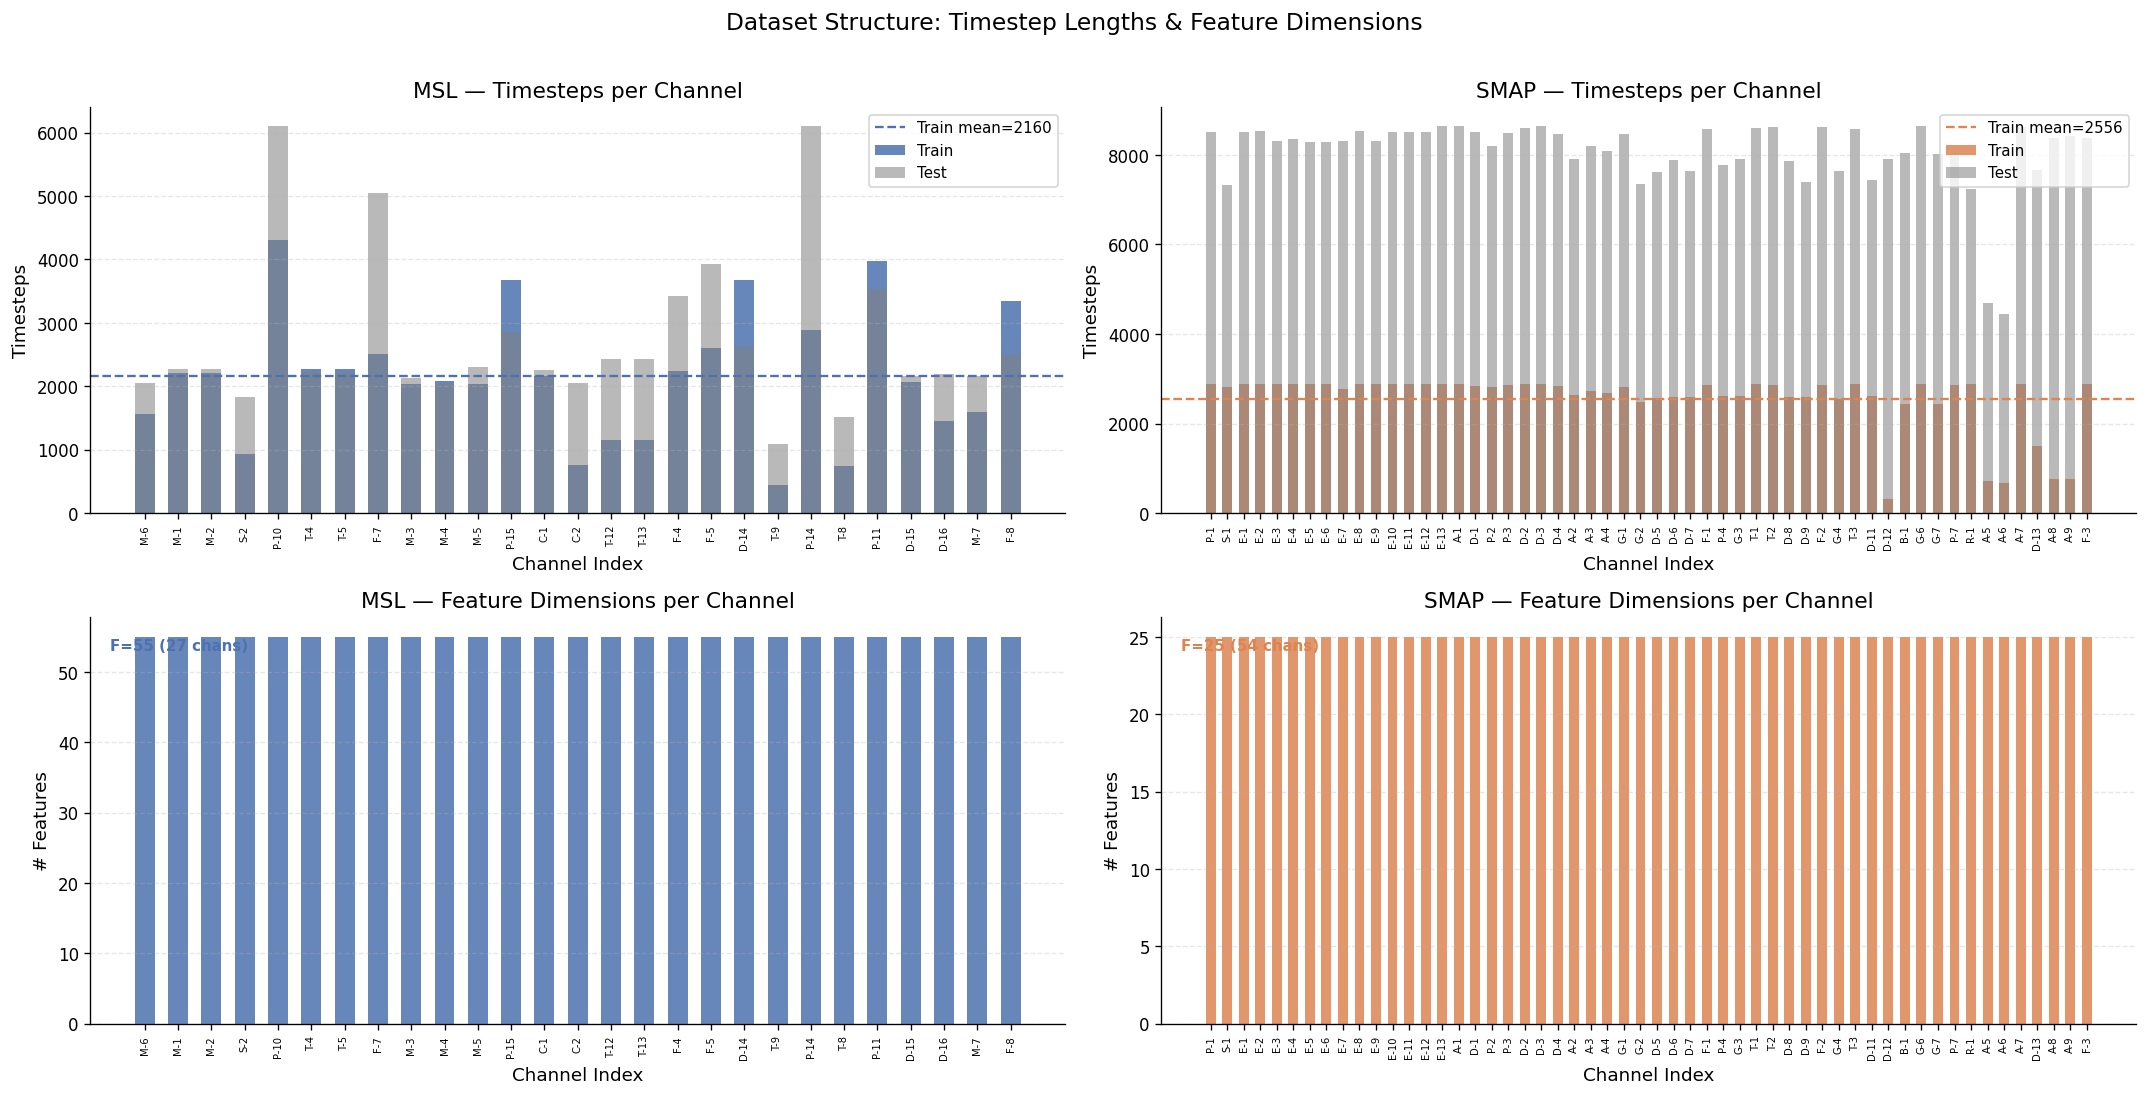

MSL:
  Train lengths  — min:439, max:4308, median:2158
  Test lengths   — min:1096, max:6100, median:2277
  Feature dims   : [np.int64(55)]
SMAP:
  Train lengths  — min:312, max:2881, median:2851
  Test lengths   — min:4453, max:8640, median:8308
  Feature dims   : [np.int64(25)]


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 9))

for col, (summary, name, color) in enumerate(zip(
        [msl_summary, smap_summary], ['MSL', 'SMAP'],
        [PALETTE['MSL'], PALETTE['SMAP']])):

    # ── Row 0: timestep lengths ──
    ax = axes[0, col]
    x  = np.arange(len(summary))
    ax.bar(x, summary['train_steps'], alpha=0.85, color=color,   label='Train', width=0.6)
    ax.bar(x, summary['test_steps'],  alpha=0.55, color='gray',  label='Test',  width=0.6)
    ax.set_title(f"{name} — Timesteps per Channel")
    ax.set_xlabel("Channel Index"); ax.set_ylabel("Timesteps")
    ax.set_xticks(x); ax.set_xticklabels(summary['channel'], rotation=90, fontsize=6)
    ax.legend(); ax.grid(axis='y')

    # Add mean line
    ax.axhline(summary['train_steps'].mean(), color=color, linestyle='--',
               linewidth=1.4, label=f"Train mean={summary['train_steps'].mean():.0f}")
    ax.legend(fontsize=9)

    # ── Row 1: feature dims ──
    ax = axes[1, col]
    ax.bar(x, summary['features'], color=color, alpha=0.85, width=0.6)
    ax.set_title(f"{name} — Feature Dimensions per Channel")
    ax.set_xlabel("Channel Index"); ax.set_ylabel("# Features")
    ax.set_xticks(x); ax.set_xticklabels(summary['channel'], rotation=90, fontsize=6)
    ax.grid(axis='y')

    # Annotate unique feature counts
    for f_val in summary['features'].unique():
        count = (summary['features'] == f_val).sum()
        ax.annotate(f"F={f_val} ({count} chans)",
                    xy=(0.02, 0.92), xycoords='axes fraction', fontsize=9,
                    color=color, fontweight='bold')

plt.suptitle("Dataset Structure: Timestep Lengths & Feature Dimensions", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# Print summary stats
for name, summary in [("MSL", msl_summary), ("SMAP", smap_summary)]:
    print(f"{name}:")
    print(f"  Train lengths  — min:{summary['train_steps'].min()}, "
          f"max:{summary['train_steps'].max()}, "
          f"median:{summary['train_steps'].median():.0f}")
    print(f"  Test lengths   — min:{summary['test_steps'].min()}, "
          f"max:{summary['test_steps'].max()}, "
          f"median:{summary['test_steps'].median():.0f}")
    print(f"  Feature dims   : {sorted(summary['features'].unique())}")


> **Key Observations:**
> - SMAP channels are significantly **longer** than MSL channels — the primary reason why `stride=1` windowing
>   causes a `MemoryError` (addressed in Section 21)
> - MSL features are **high-dimensional** (≈25 features) while most SMAP channels are **univariate** (1 feature)
> - This means the two datasets test complementary aspects of MEMTO:
>   - MSL → tests **multivariate cross-feature attention** within the Transformer
>   - SMAP → tests **long-sequence temporal memory** in the memory module


<a id='8'></a>
## 8. Class Imbalance Analysis

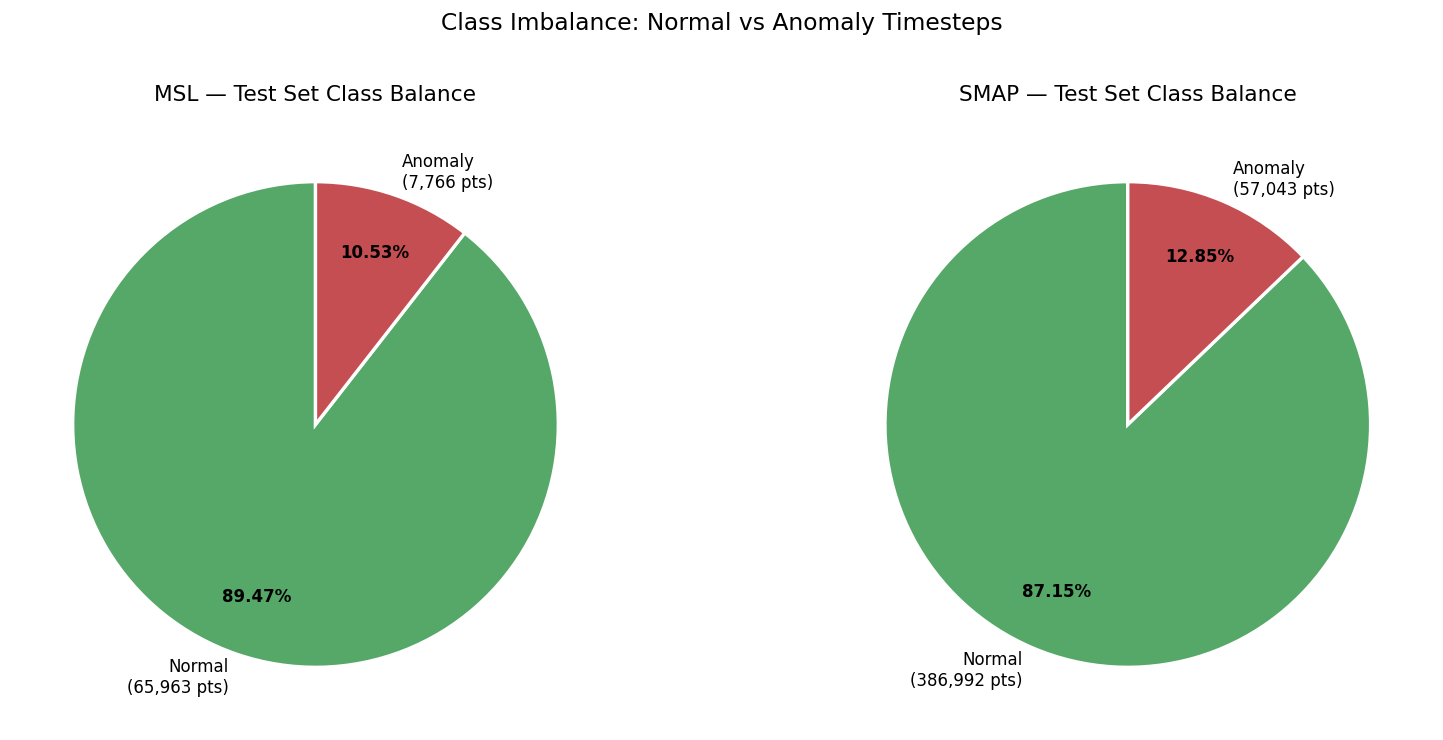

In [11]:
def parse_seqs(seq_str):
    try:    return ast.literal_eval(seq_str)
    except: return []

def compute_anomaly_stats(label_df, test_dict):
    rows = []
    for _, row in label_df.iterrows():
        chan  = row['chan_id']
        seqs  = parse_seqs(row['anomaly_sequences'])
        total = test_dict[chan].shape[0] if chan in test_dict else 0
        anom  = sum(e - s + 1 for s, e in seqs)
        rows.append({
            'channel'     : chan,
            'num_seqs'    : len(seqs),
            'anomaly_pts' : anom,
            'normal_pts'  : total - anom,
            'total_pts'   : total,
            'anomaly_pct' : round(100 * anom / total, 3) if total else 0,
        })
    return pd.DataFrame(rows)

msl_anom  = compute_anomaly_stats(msl_labels, msl_test)
smap_anom = compute_anomaly_stats(smap_labels, smap_test)

# ── Plot 1: Pie charts (overall balance) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, stats, name in zip(axes, [msl_anom, smap_anom], ['MSL', 'SMAP']):
    total_normal = stats['normal_pts'].sum()
    total_anom   = stats['anomaly_pts'].sum()
    wedges, texts, autotexts = ax.pie(
        [total_normal, total_anom],
        labels=[f'Normal\n({total_normal:,} pts)', f'Anomaly\n({total_anom:,} pts)'],
        colors=[PALETTE['normal'], PALETTE['anomaly']],
        autopct='%1.2f%%', startangle=90, pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    for at in autotexts: at.set_fontweight('bold')
    ax.set_title(f"{name} — Test Set Class Balance", fontsize=13, pad=12)

plt.suptitle("Class Imbalance: Normal vs Anomaly Timesteps", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


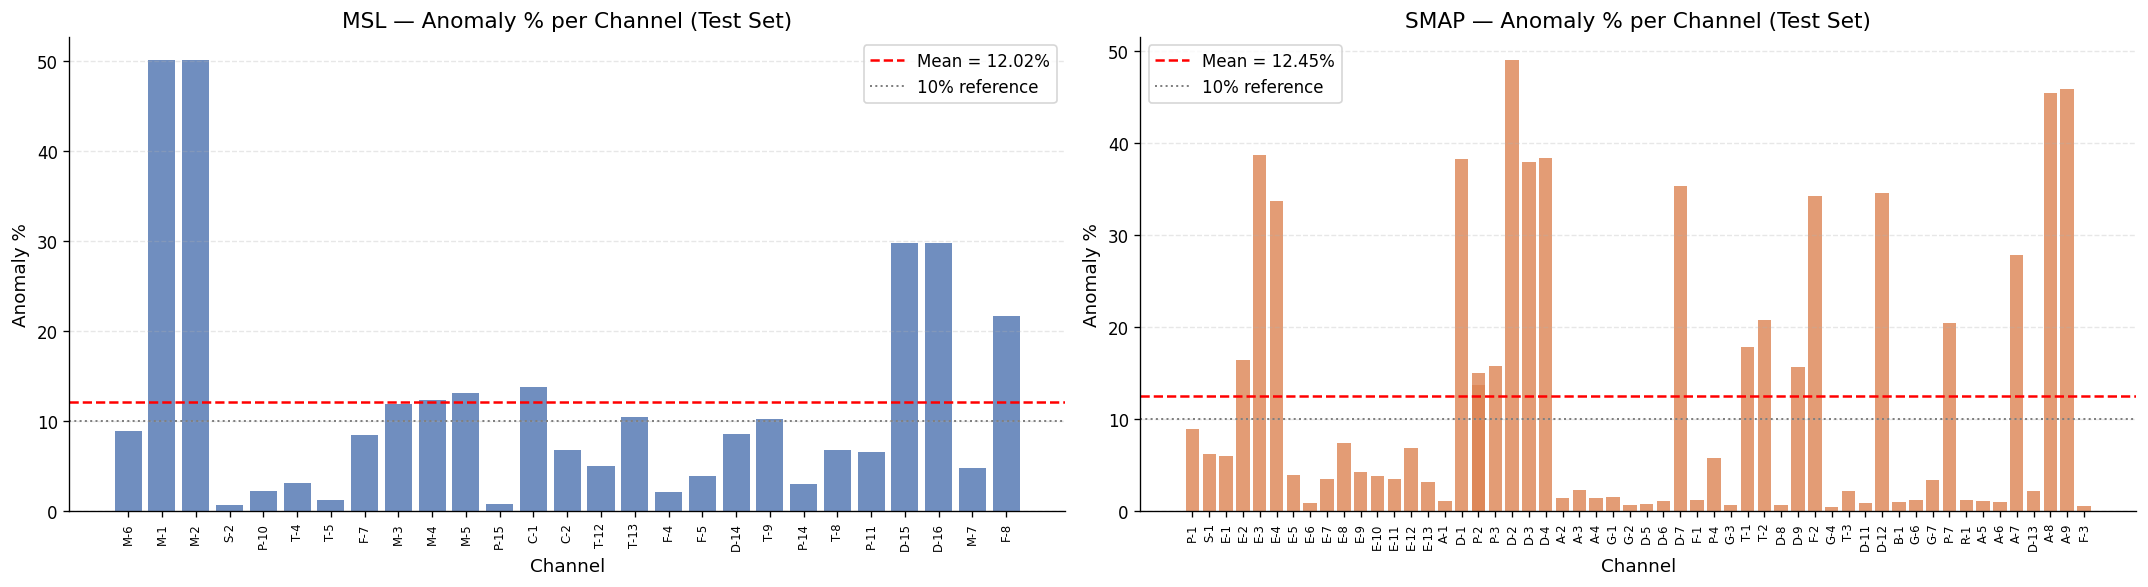

MSL   — mean anomaly%: 12.02%  |  imbalance ratio ≈ 1:7  |  max: 50.11%  |  min: 0.60%
SMAP  — mean anomaly%: 12.45%  |  imbalance ratio ≈ 1:7  |  max: 49.08%  |  min: 0.41%


In [12]:
# ── Plot 2: Per-channel anomaly % bar chart ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, stats, name, color in zip(axes,
        [msl_anom, smap_anom], ['MSL', 'SMAP'],
        [PALETTE['MSL'], PALETTE['SMAP']]):

    bars = ax.bar(stats['channel'], stats['anomaly_pct'], color=color, alpha=0.8, edgecolor='none')
    ax.axhline(stats['anomaly_pct'].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f"Mean = {stats['anomaly_pct'].mean():.2f}%")
    ax.axhline(10, color='gray', linestyle=':', linewidth=1.2, label="10% reference")
    ax.set_title(f"{name} — Anomaly % per Channel (Test Set)")
    ax.set_xlabel("Channel"); ax.set_ylabel("Anomaly %")
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.legend(); ax.grid(axis='y')

plt.tight_layout(); plt.show()

# Imbalance ratio summary
for name, stats in [("MSL", msl_anom), ("SMAP", smap_anom)]:
    mean_pct = stats['anomaly_pct'].mean()
    ratio    = int(100 / mean_pct) - 1
    print(f"{name:5s} — mean anomaly%: {mean_pct:.2f}%  |  "
          f"imbalance ratio ≈ 1:{ratio}  |  "
          f"max: {stats['anomaly_pct'].max():.2f}%  |  "
          f"min: {stats['anomaly_pct'].min():.2f}%")


> **Critical Implications for MEMTO Evaluation:**
> - Both datasets are **heavily imbalanced** — anomalies represent only ~5–15% of test timesteps
> - Standard **accuracy is misleading**: a naive "predict all normal" model gets 85–95% accuracy
> - The MEMTO paper correctly uses **F1-score with the point-adjust strategy**:
>   once any window overlapping an anomaly is flagged, all timesteps in that anomaly sequence are counted as detected
> - **Threshold selection** at inference time must account for this skew —
>   the reconstruction error distribution is dominated by normal examples


<a id='9'></a>
## 9. Anomaly Sequence & Duration Analysis

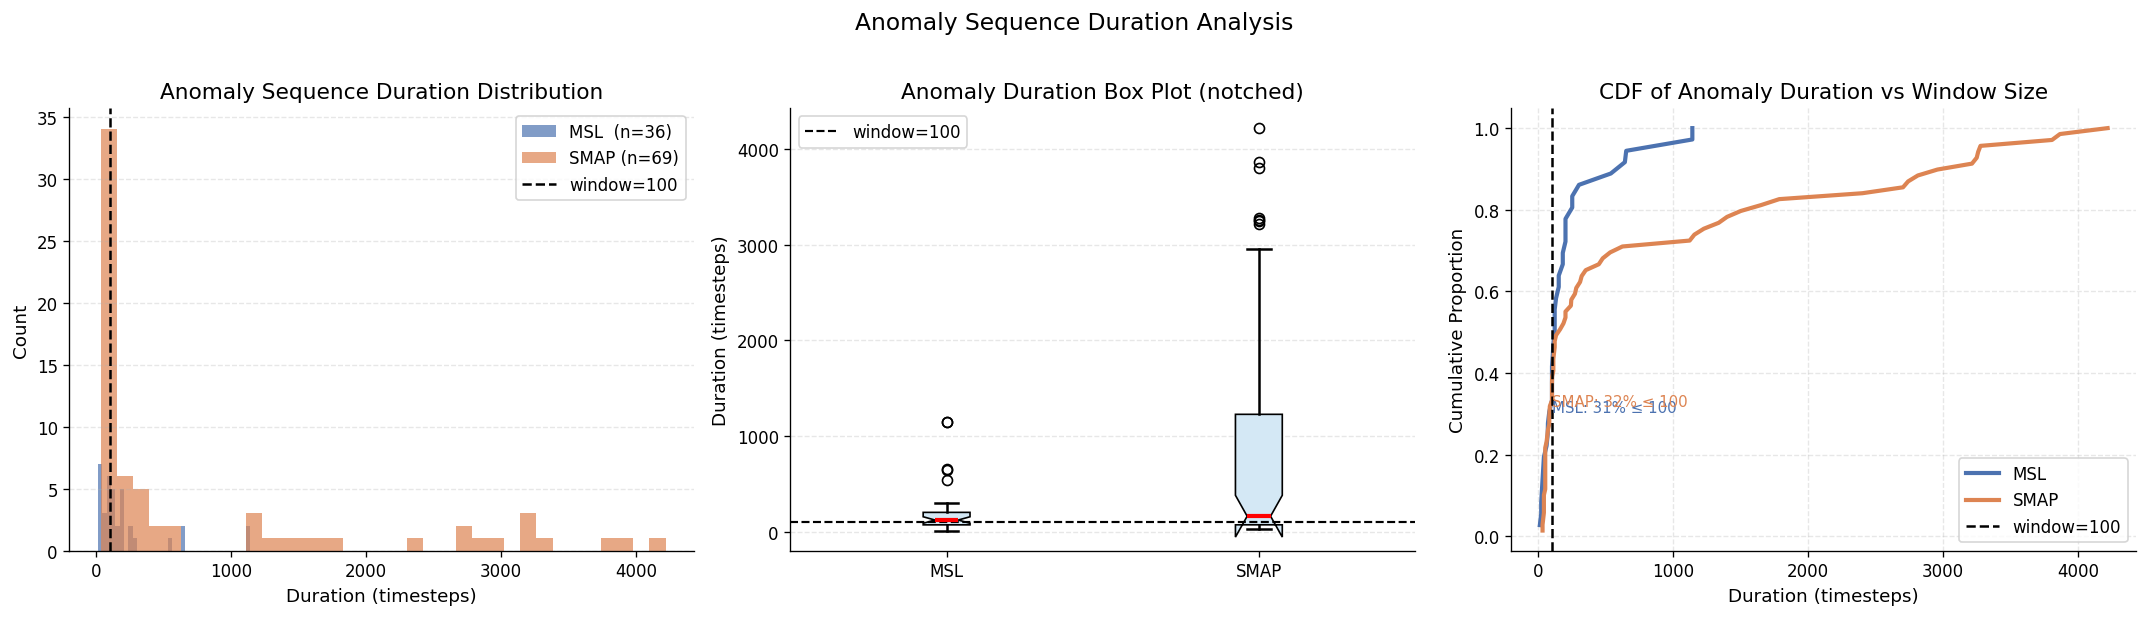

,Metric,MSL,SMAP
0,Count,36,69
1,Min,11,31
2,Max,1141,4218
3,Mean,215.7,826.7
4,Median,121.0,161.0
5,Std,271.4,1189.1
6,% ≤ window(100),30.6%,31.9%


In [13]:
def get_durations(label_df):
    durations = []
    for _, row in label_df.iterrows():
        for s, e in parse_seqs(row['anomaly_sequences']):
            durations.append(e - s + 1)
    return durations

msl_dur  = get_durations(msl_labels)
smap_dur = get_durations(smap_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Histogram ──
ax = axes[0]
ax.hist(msl_dur,  bins=35, alpha=0.7, color=PALETTE['MSL'],  label=f'MSL  (n={len(msl_dur)})',  edgecolor='none')
ax.hist(smap_dur, bins=35, alpha=0.7, color=PALETTE['SMAP'], label=f'SMAP (n={len(smap_dur)})', edgecolor='none')
ax.axvline(100, color='black', linestyle='--', linewidth=1.5, label='window=100')
ax.set_title("Anomaly Sequence Duration Distribution")
ax.set_xlabel("Duration (timesteps)"); ax.set_ylabel("Count")
ax.legend(); ax.grid(axis='y')

# ── Box plot ──
ax = axes[1]
bp = ax.boxplot([msl_dur, smap_dur], labels=['MSL', 'SMAP'],
                patch_artist=True, notch=True,
                boxprops=dict(facecolor='#d4e8f5'),
                medianprops=dict(color='red', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))
ax.axhline(100, color='black', linestyle='--', linewidth=1.3, label='window=100')
ax.set_title("Anomaly Duration Box Plot (notched)")
ax.set_ylabel("Duration (timesteps)")
ax.legend(); ax.grid(axis='y')

# ── CDF ──
ax = axes[2]
for dur, name, color in [(msl_dur,'MSL',PALETTE['MSL']),(smap_dur,'SMAP',PALETTE['SMAP'])]:
    sorted_d = np.sort(dur)
    cdf = np.arange(1, len(sorted_d)+1) / len(sorted_d)
    ax.plot(sorted_d, cdf, color=color, label=name, linewidth=2.5)
    pct_under_100 = 100 * np.mean(np.array(dur) <= 100)
    ax.annotate(f"{name}: {pct_under_100:.0f}% ≤ 100",
                xy=(100, pct_under_100/100), xycoords='data',
                fontsize=9, ha='left', color=color)
ax.axvline(100, color='black', linestyle='--', linewidth=1.5, label='window=100')
ax.set_title("CDF of Anomaly Duration vs Window Size")
ax.set_xlabel("Duration (timesteps)"); ax.set_ylabel("Cumulative Proportion")
ax.legend(); ax.grid()

plt.suptitle("Anomaly Sequence Duration Analysis", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Stats table
dur_stats = pd.DataFrame({
    'Metric'  : ['Count','Min','Max','Mean','Median','Std','% ≤ window(100)'],
    'MSL'     : [len(msl_dur), min(msl_dur), max(msl_dur),
                 f"{np.mean(msl_dur):.1f}", f"{np.median(msl_dur):.1f}",
                 f"{np.std(msl_dur):.1f}",
                 f"{100*np.mean(np.array(msl_dur)<=100):.1f}%"],
    'SMAP'    : [len(smap_dur), min(smap_dur), max(smap_dur),
                 f"{np.mean(smap_dur):.1f}", f"{np.median(smap_dur):.1f}",
                 f"{np.std(smap_dur):.1f}",
                 f"{100*np.mean(np.array(smap_dur)<=100):.1f}%"],
})
display(dur_stats)


> **Why this justifies `window_size=100`:**
> - The CDF shows what percentage of anomalies are **fully contained** within a single window
> - If an anomaly is fully contained in one window → that window has high reconstruction error → easy to detect
> - Very short anomalies (< 10 steps) occupy only ~10% of any window — these produce only a small error signal
> - Very long anomalies (>> 100 steps) span multiple windows — easier to detect, handled by point-adjust strategy
> - The MEMTO paper's `window_size=100` is validated by this distribution


<a id='10'></a>
## 10. Anomaly vs Normal Segment Statistics

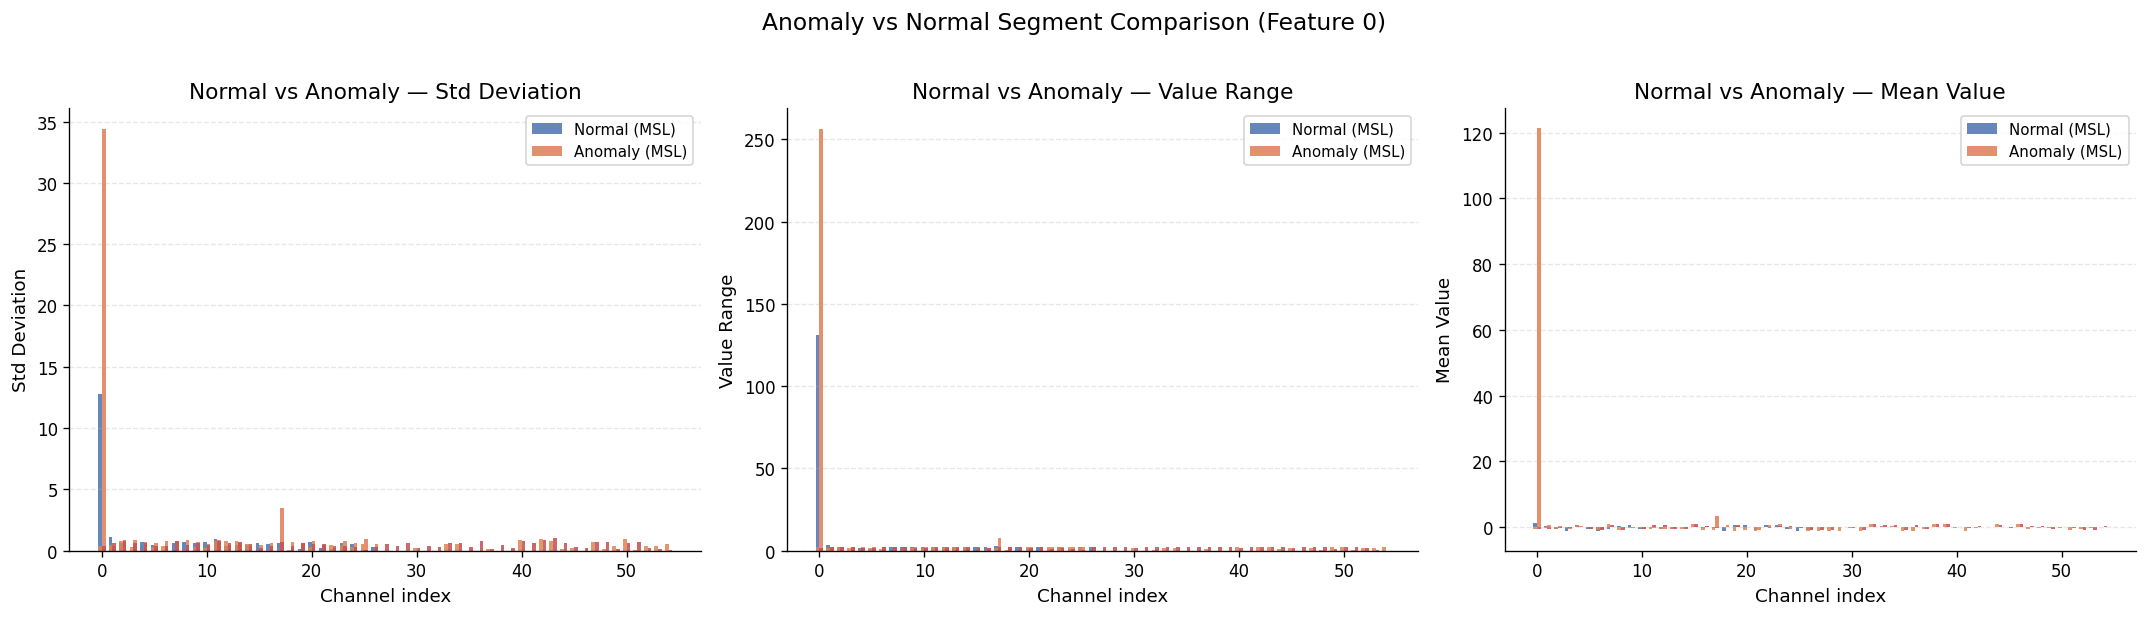

MSL: 9/27 channels with Cohen's d > 0.8 (large effect)
       21/27 channels where anomaly std > normal std
SMAP: 24/55 channels with Cohen's d > 0.8 (large effect)
       38/55 channels where anomaly std > normal std


In [14]:
def anomaly_vs_normal_stats(test_arr, anomaly_seqs, chan):
    sig  = test_arr[:, 0] if test_arr.ndim > 1 else test_arr
    mask = np.zeros(len(sig), dtype=bool)
    for s, e in anomaly_seqs:
        mask[s:e+1] = True

    normal_seg  = sig[~mask]
    anomaly_seg = sig[mask]
    if len(anomaly_seg) == 0:
        return None

    # Cohen's d — effect size
    pooled_std = np.sqrt((normal_seg.std()**2 + anomaly_seg.std()**2) / 2)
    cohens_d   = abs(anomaly_seg.mean() - normal_seg.mean()) / (pooled_std + 1e-9)

    return {
        'channel'       : chan,
        'normal_mean'   : round(float(normal_seg.mean()),  4),
        'anomaly_mean'  : round(float(anomaly_seg.mean()), 4),
        'normal_std'    : round(float(normal_seg.std()),   4),
        'anomaly_std'   : round(float(anomaly_seg.std()),  4),
        'normal_range'  : round(float(normal_seg.max() - normal_seg.min()),   4),
        'anomaly_range' : round(float(anomaly_seg.max() - anomaly_seg.min()), 4),
        'mean_shift'    : round(abs(float(anomaly_seg.mean()) - float(normal_seg.mean())), 4),
        'std_ratio'     : round(float(anomaly_seg.std()) / (float(normal_seg.std()) + 1e-9), 4),
        'cohens_d'      : round(float(cohens_d), 4),
    }

def build_stats_df(label_df, test_dict):
    rows = []
    for _, row in label_df.iterrows():
        chan = row['chan_id']
        if chan not in test_dict: continue
        seqs = parse_seqs(row['anomaly_sequences'])
        r = anomaly_vs_normal_stats(test_dict[chan], seqs, chan)
        if r: rows.append(r)
    return pd.DataFrame(rows)

msl_seg_stats  = build_stats_df(msl_labels,  msl_test)
smap_seg_stats = build_stats_df(smap_labels, smap_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [
    ('normal_std',   'anomaly_std',   'Std Deviation'),
    ('normal_range', 'anomaly_range', 'Value Range'),
    ('normal_mean',  'anomaly_mean',  'Mean Value'),
]

for ax, (nk, ak, title) in zip(axes, metrics):
    width = 0.35
    for i, (stats, name, c_norm, c_anom) in enumerate([
            (msl_seg_stats,  'MSL',  PALETTE['MSL'],  '#e07b54'),
            (smap_seg_stats, 'SMAP', PALETTE['SMAP'], '#c44e52')]):
        x = np.arange(len(stats))
        ax.bar(x - width/2, stats[nk], width, alpha=0.85, color=c_norm,
               label=f'Normal ({name})' if i == 0 else '_')
        ax.bar(x + width/2, stats[ak], width, alpha=0.85, color=c_anom,
               label=f'Anomaly ({name})' if i == 0 else '_')
    ax.set_title(f"Normal vs Anomaly — {title}")
    ax.set_xlabel("Channel index"); ax.set_ylabel(title)
    ax.legend(fontsize=9); ax.grid(axis='y')

plt.suptitle("Anomaly vs Normal Segment Comparison (Feature 0)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Effect size summary
for name, seg in [("MSL", msl_seg_stats), ("SMAP", smap_seg_stats)]:
    high_effect = (seg['cohens_d'] > 0.8).sum()
    high_std    = (seg['std_ratio'] > 1.0).sum()
    print(f"{name}: {high_effect}/{len(seg)} channels with Cohen's d > 0.8 (large effect)")
    print(f"       {high_std}/{len(seg)} channels where anomaly std > normal std")


> **Observation:** Anomalous segments typically show **higher standard deviation and wider value ranges**.
> This is the core signal MEMTO exploits — the memory module stores prototypes of *normal* patterns,
> so anomalies that deviate from these prototypes produce high reconstruction error.
>
> Channels with **small Cohen's d and similar std** (hard channels) will produce the most false negatives
> — these are the channels where MEMTO's threshold tuning is most critical.


<a id='11'></a>
## 11. MSL vs SMAP Inter-Dataset Comparison

MSL vs SMAP — Complete Comparison Table:


,Metric,MSL,SMAP
0,# Channels,27,54
1,Avg Train Length (timesteps),2160,2556
2,Avg Test Length (timesteps),2731,8071
3,Avg Feature Dimensions,55.0,25.0
4,Avg Anomaly % (test),12.02%,12.45%
5,Total Anomaly Sequences,36,69
6,Median Anomaly Duration,121,161
7,Avg Train Skewness,1.305,1.220
8,Avg Train Kurtosis,62.354,21.460


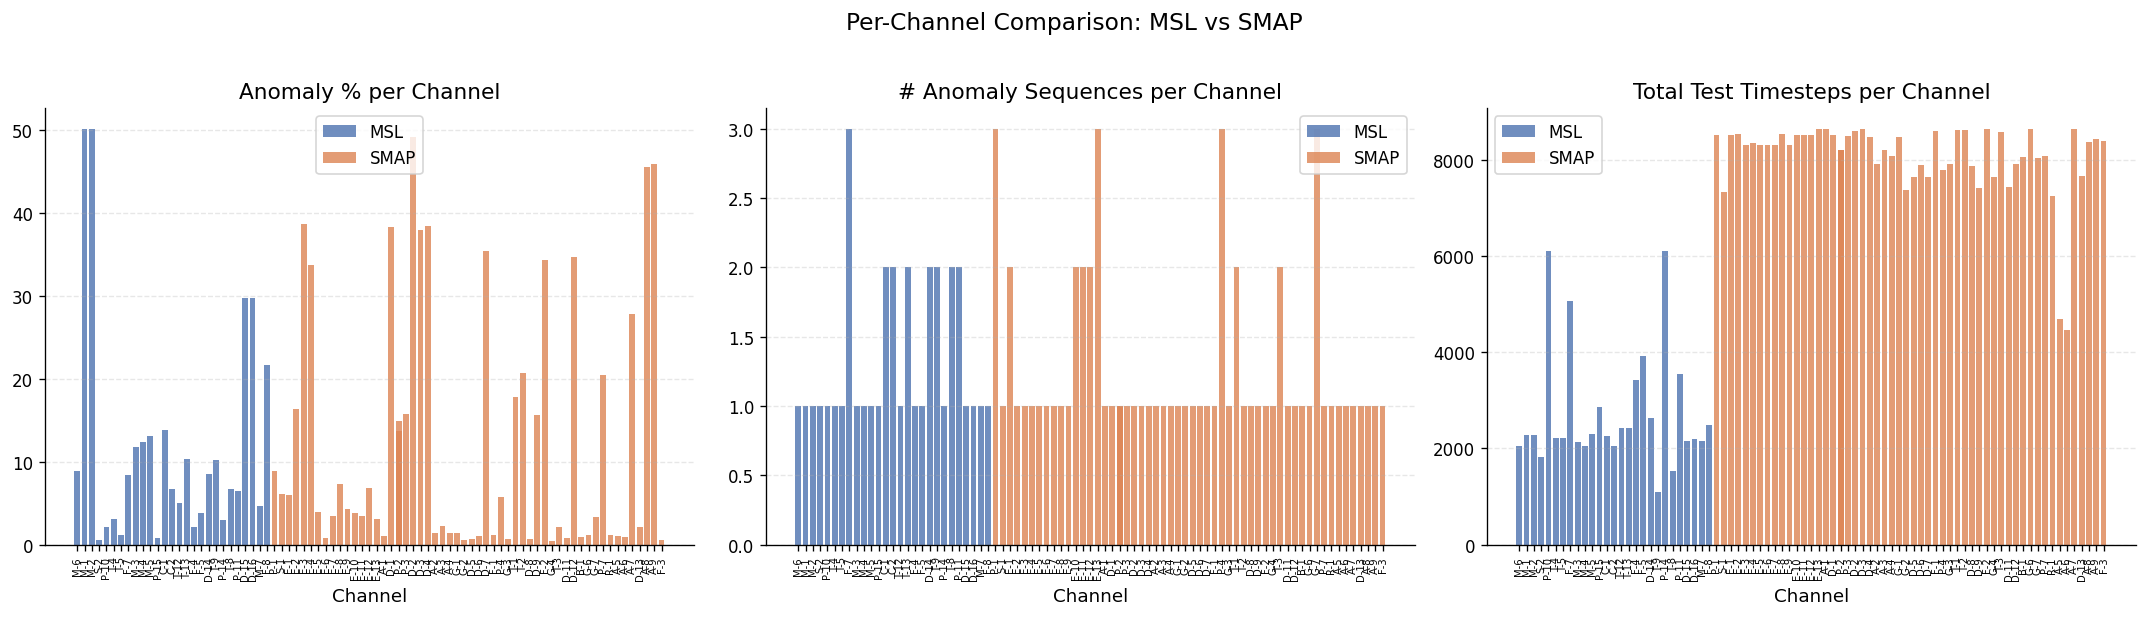

In [15]:
comparison = pd.DataFrame({
    'Metric'                    : [
        '# Channels',
        'Avg Train Length (timesteps)',
        'Avg Test Length (timesteps)',
        'Avg Feature Dimensions',
        'Avg Anomaly % (test)',
        'Total Anomaly Sequences',
        'Median Anomaly Duration',
        'Avg Train Skewness',
        'Avg Train Kurtosis',
    ],
    'MSL'  : [
        len(msl_summary),
        f"{msl_summary['train_steps'].mean():.0f}",
        f"{msl_summary['test_steps'].mean():.0f}",
        f"{msl_summary['features'].mean():.1f}",
        f"{msl_anom['anomaly_pct'].mean():.2f}%",
        int(msl_anom['num_seqs'].sum()),
        int(np.median(msl_dur)),
        f"{msl_summary['train_skew'].mean():.3f}",
        f"{msl_summary['train_kurt'].mean():.3f}",
    ],
    'SMAP' : [
        len(smap_summary),
        f"{smap_summary['train_steps'].mean():.0f}",
        f"{smap_summary['test_steps'].mean():.0f}",
        f"{smap_summary['features'].mean():.1f}",
        f"{smap_anom['anomaly_pct'].mean():.2f}%",
        int(smap_anom['num_seqs'].sum()),
        int(np.median(smap_dur)),
        f"{smap_summary['train_skew'].mean():.3f}",
        f"{smap_summary['train_kurt'].mean():.3f}",
    ],
})
print("MSL vs SMAP — Complete Comparison Table:")
display(comparison)

# ── Visual comparison bar chart ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_vis = [
    ('anomaly_pct',  'Anomaly % per Channel'),
    ('num_seqs',     '# Anomaly Sequences per Channel'),
    ('total_pts',    'Total Test Timesteps per Channel'),
]
for ax, (col, title) in zip(axes, metrics_vis):
    all_chans = sorted(set(msl_anom['channel'].tolist() + smap_anom['channel'].tolist()))
    ax.bar(msl_anom['channel'],  msl_anom[col],  color=PALETTE['MSL'],  alpha=0.8, label='MSL')
    ax.bar(smap_anom['channel'], smap_anom[col], color=PALETTE['SMAP'], alpha=0.8, label='SMAP')
    ax.set_title(title); ax.set_xlabel("Channel")
    ax.tick_params(axis='x', rotation=90, labelsize=6)
    ax.legend(); ax.grid(axis='y')

plt.suptitle("Per-Channel Comparison: MSL vs SMAP", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


> **Key Differences — Implications for MEMTO:**
> - **SMAP**: far more channels + longer sequences → primary source of `MemoryError` with naive windowing
> - **MSL**: higher feature dimensions → exercises MEMTO's **cross-feature Transformer attention**
> - **SMAP's** slightly higher anomaly % makes threshold tuning somewhat easier than MSL
> - **Evaluate each dataset separately** — a single threshold does not transfer across datasets


<a id='12'></a>
## 12. Time-Series Visualization with Anomaly Overlays

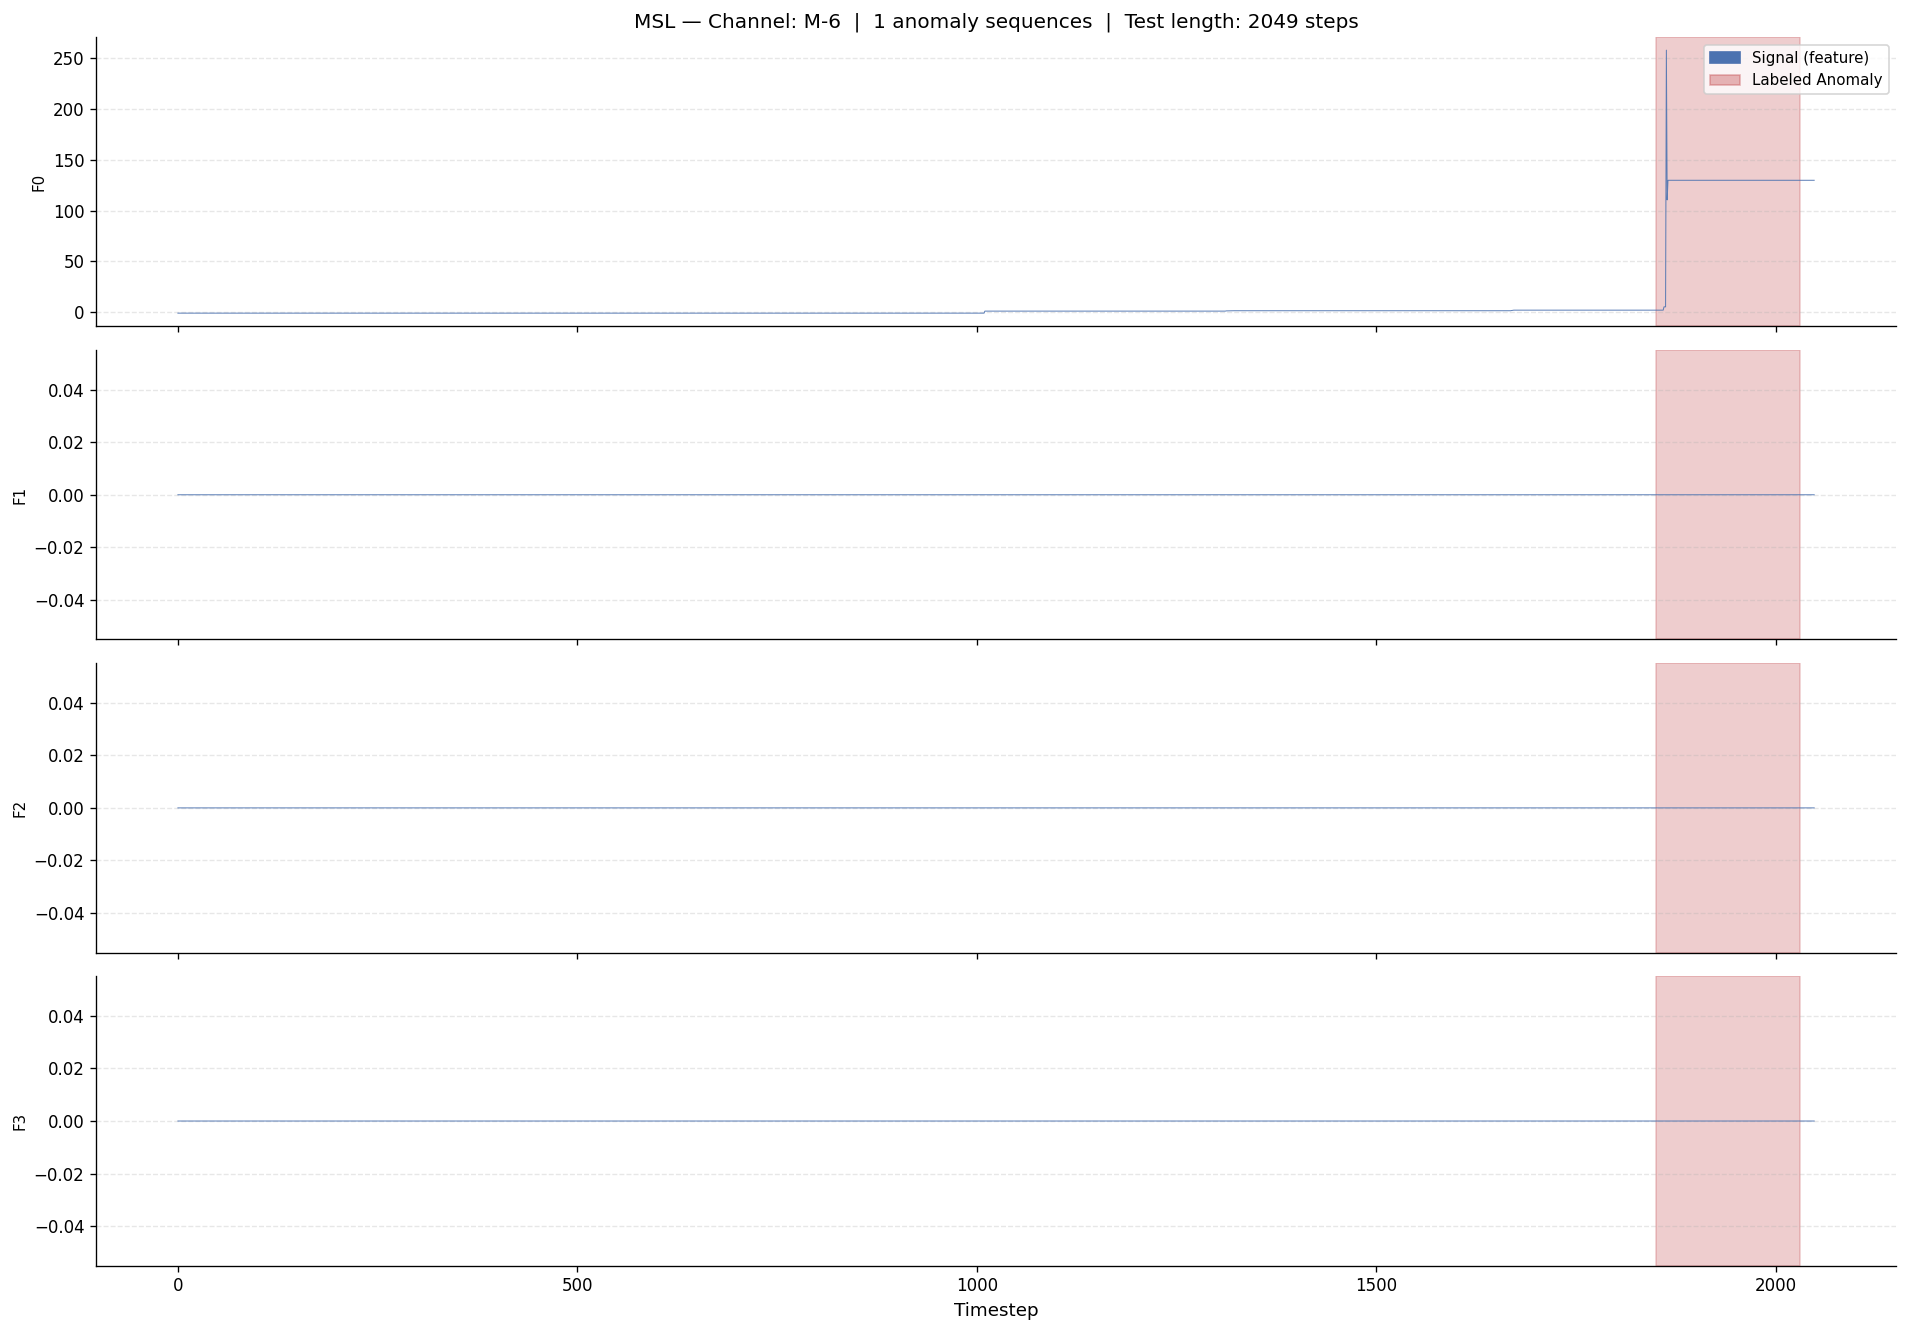

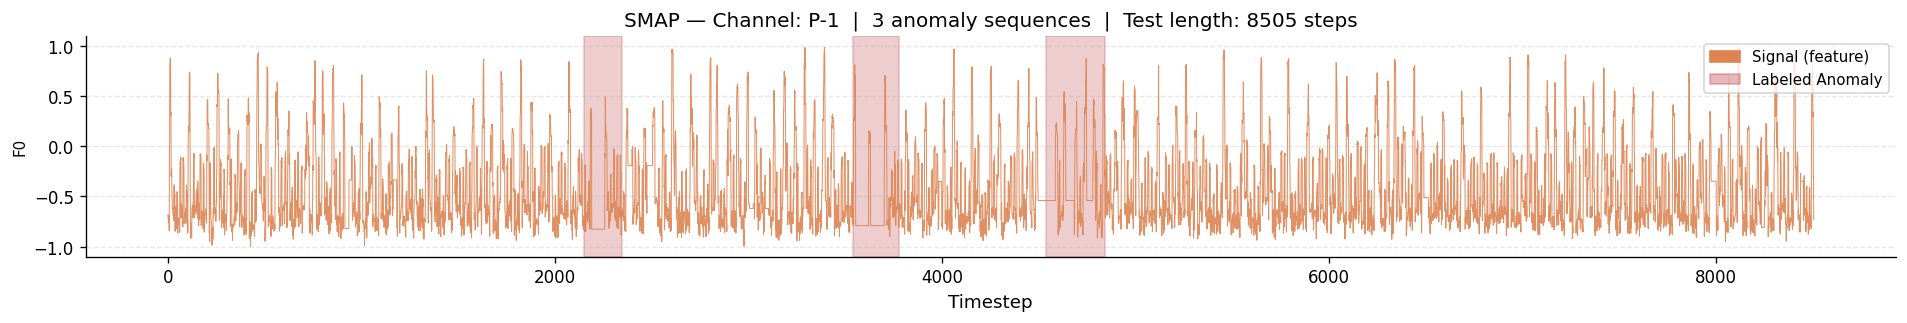

In [16]:
def plot_channel(chan, test_arr, label_row, dataset_name, color, max_features=4):
    seqs = parse_seqs(label_row['anomaly_sequences'].values[0])
    n_feat = test_arr.shape[1] if test_arr.ndim > 1 else 1
    n_show = min(n_feat, max_features)
    arr    = test_arr if test_arr.ndim > 1 else test_arr.reshape(-1, 1)

    fig, axes = plt.subplots(n_show, 1, figsize=(16, 2.8 * n_show), sharex=True)
    if n_show == 1: axes = [axes]

    for fi, ax in enumerate(axes):
        sig = arr[:, fi]
        ax.plot(sig, color=color, linewidth=0.6, alpha=0.9)
        for s, e in seqs:
            ax.axvspan(s, e, color=PALETTE['anomaly'], alpha=0.28)
        ax.set_ylabel(f"F{fi}", fontsize=9)
        ax.grid(axis='y')

    handles = [mpatches.Patch(color=color, label='Signal (feature)'),
               mpatches.Patch(color=PALETTE['anomaly'], alpha=0.4, label='Labeled Anomaly')]
    axes[0].legend(handles=handles, loc='upper right', fontsize=9)
    axes[0].set_title(f"{dataset_name} — Channel: {chan}  |  "
                      f"{len(seqs)} anomaly sequences  |  "
                      f"Test length: {len(arr)} steps", fontsize=12)
    axes[-1].set_xlabel("Timestep")

    plt.tight_layout(); plt.show()

sample_msl  = msl_labels.iloc[0]['chan_id']
sample_smap = smap_labels.iloc[0]['chan_id']

plot_channel(sample_msl,  msl_test[sample_msl],
             msl_labels[msl_labels['chan_id'] == sample_msl], "MSL",  PALETTE['MSL'],  max_features=4)
plot_channel(sample_smap, smap_test[sample_smap],
             smap_labels[smap_labels['chan_id'] == sample_smap], "SMAP", PALETTE['SMAP'], max_features=1)


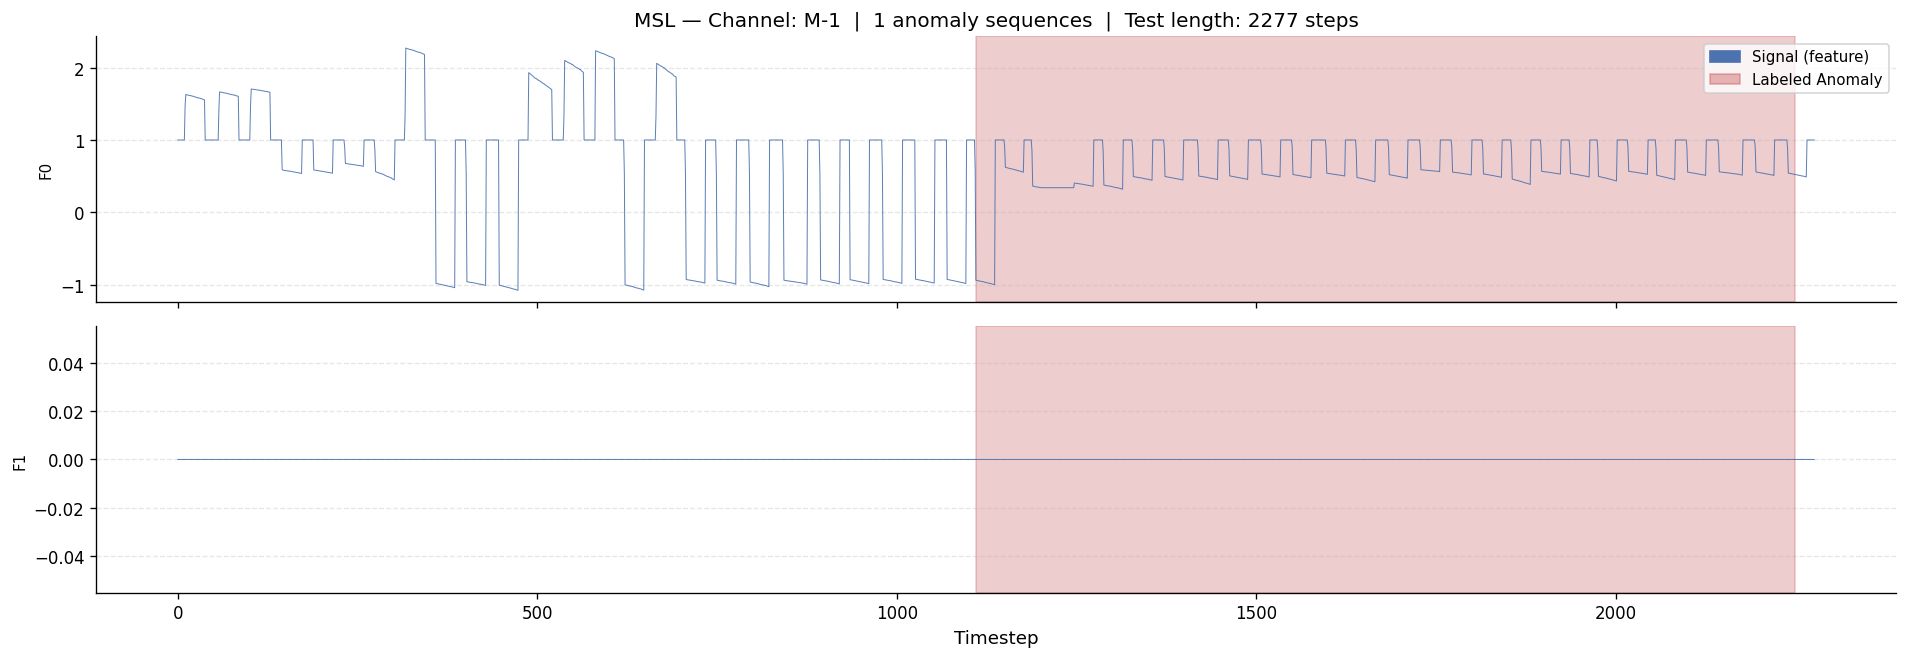

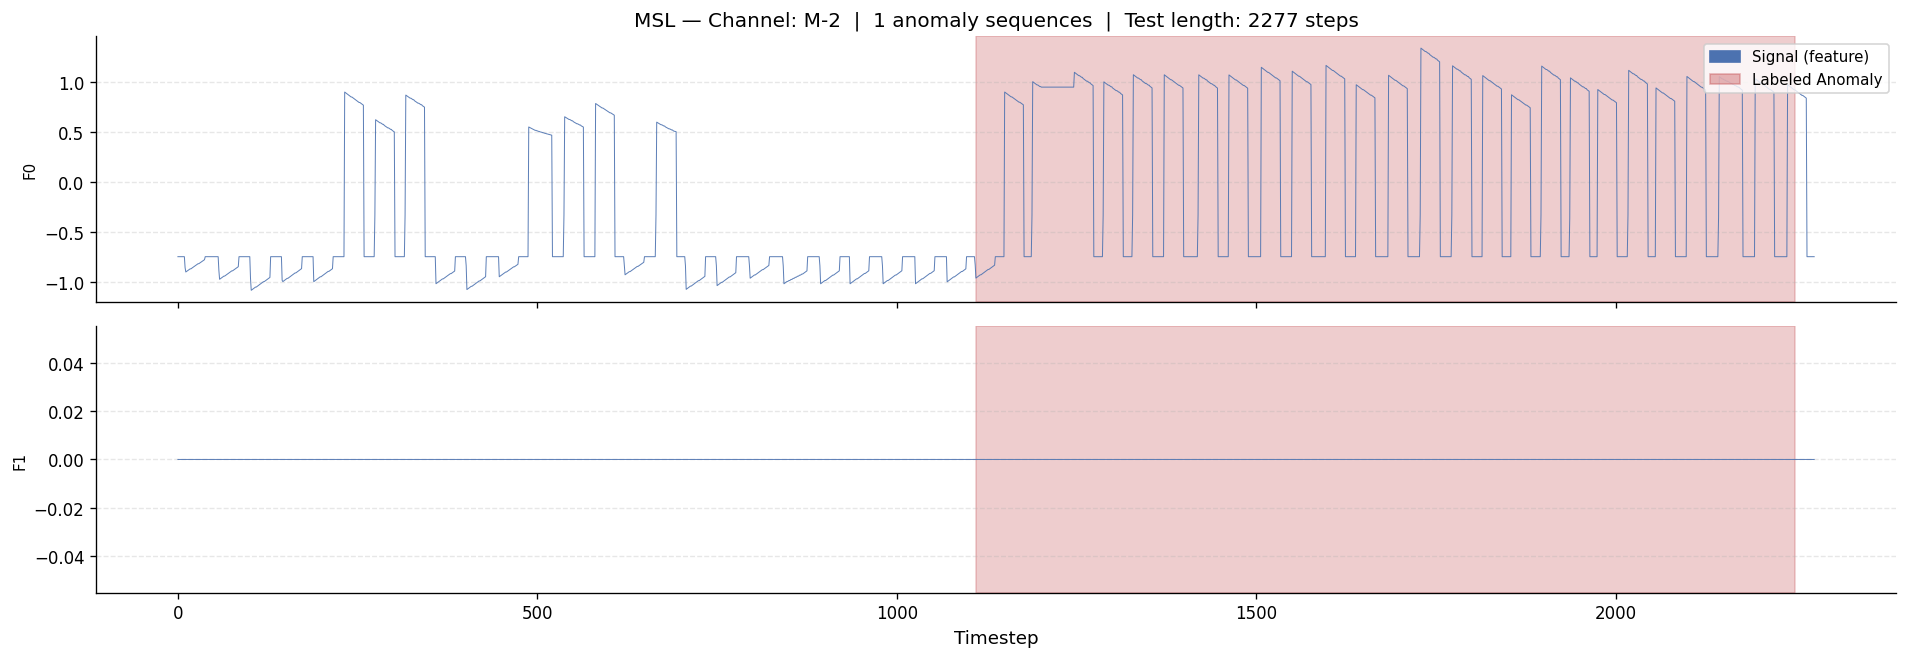

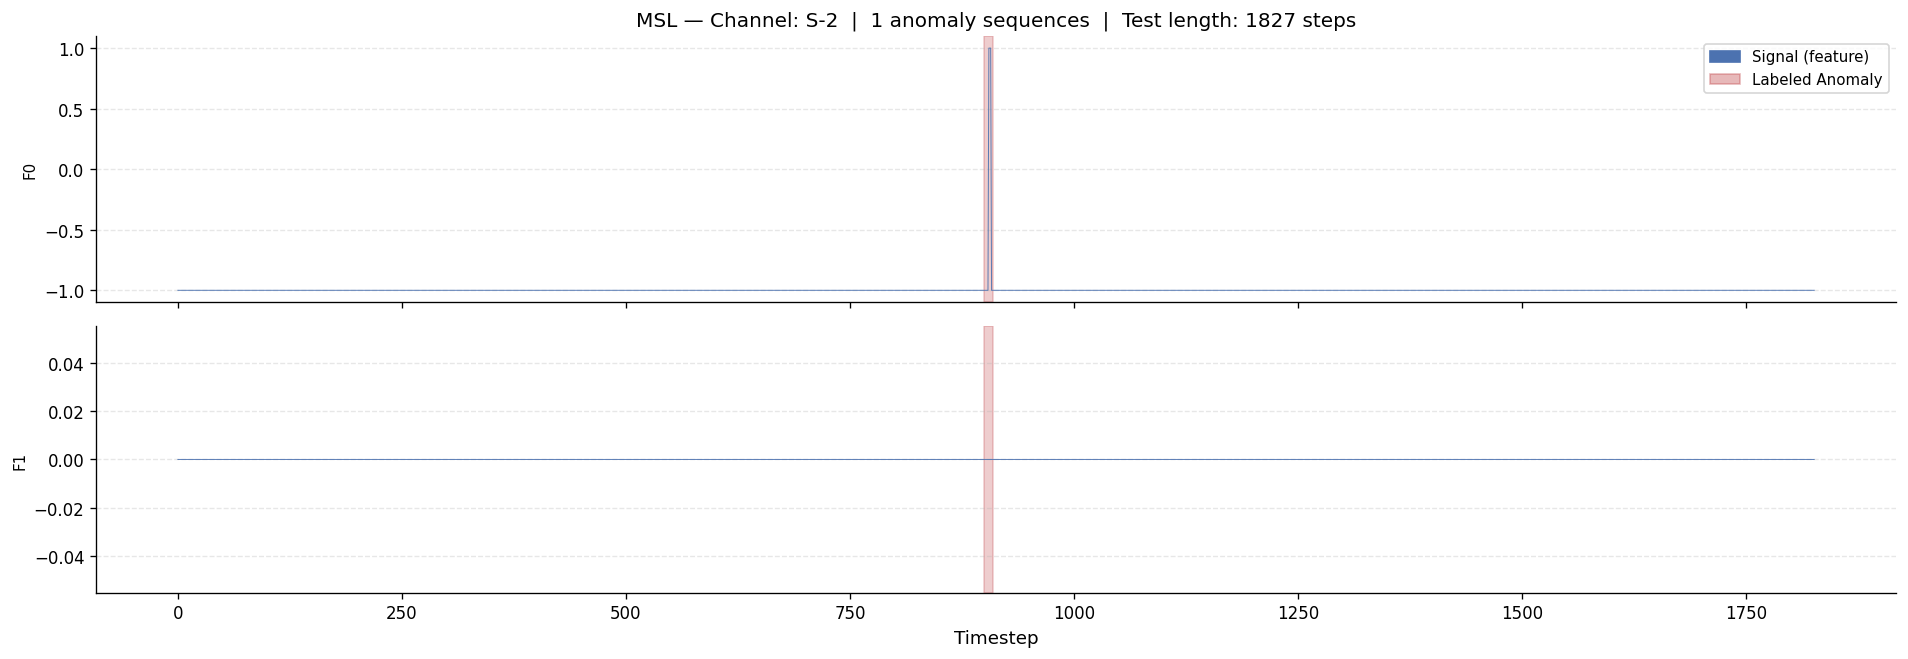

In [17]:
# Visualize 3 additional channels for diversity
for i in range(1, 4):
    if i < len(msl_labels):
        chan = msl_labels.iloc[i]['chan_id']
        plot_channel(chan, msl_test[chan],
                     msl_labels[msl_labels['chan_id'] == chan], "MSL", PALETTE['MSL'], max_features=2)


<a id='13'></a>
## 13. Feature Value Distributions

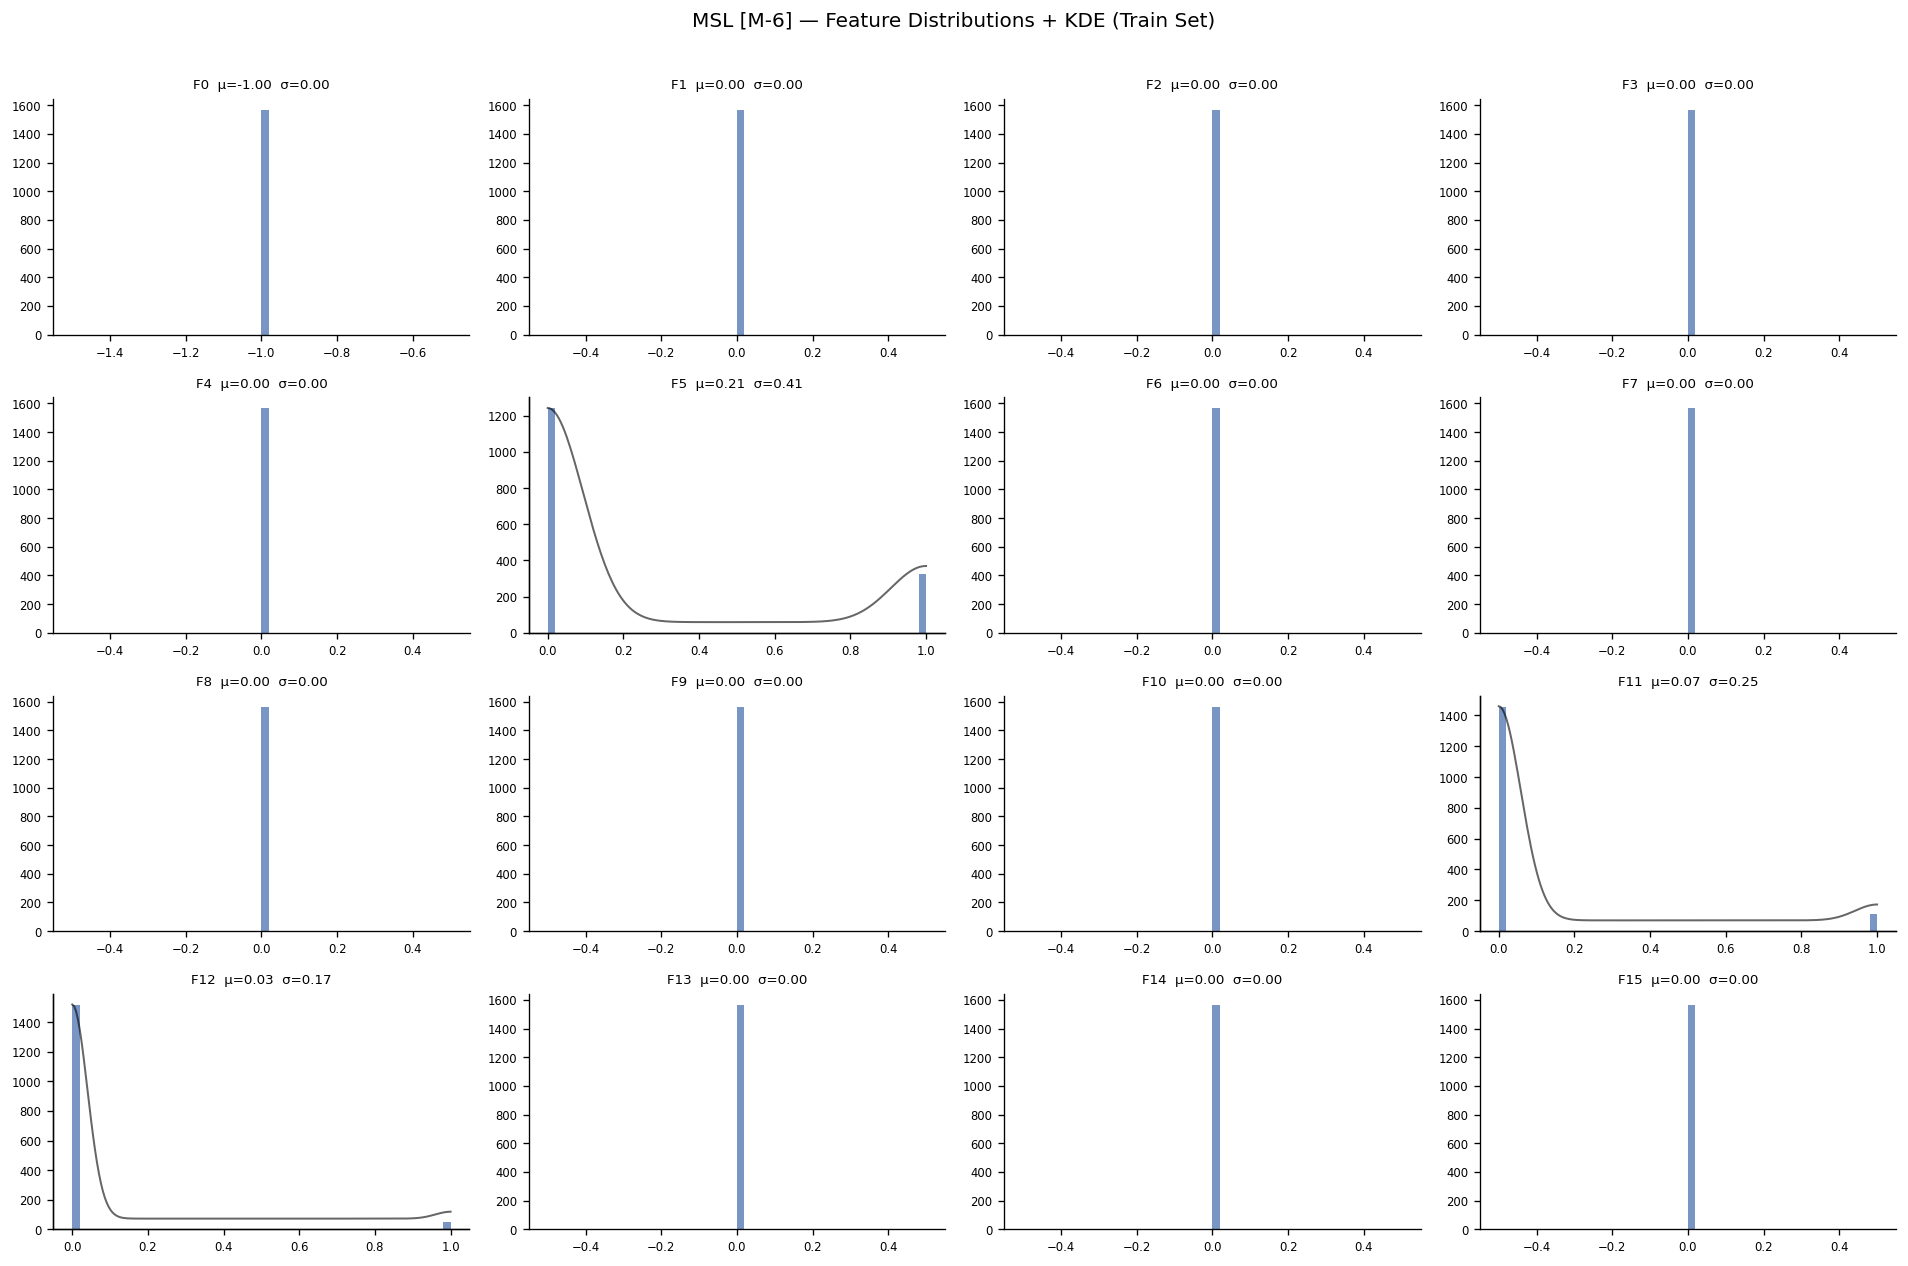

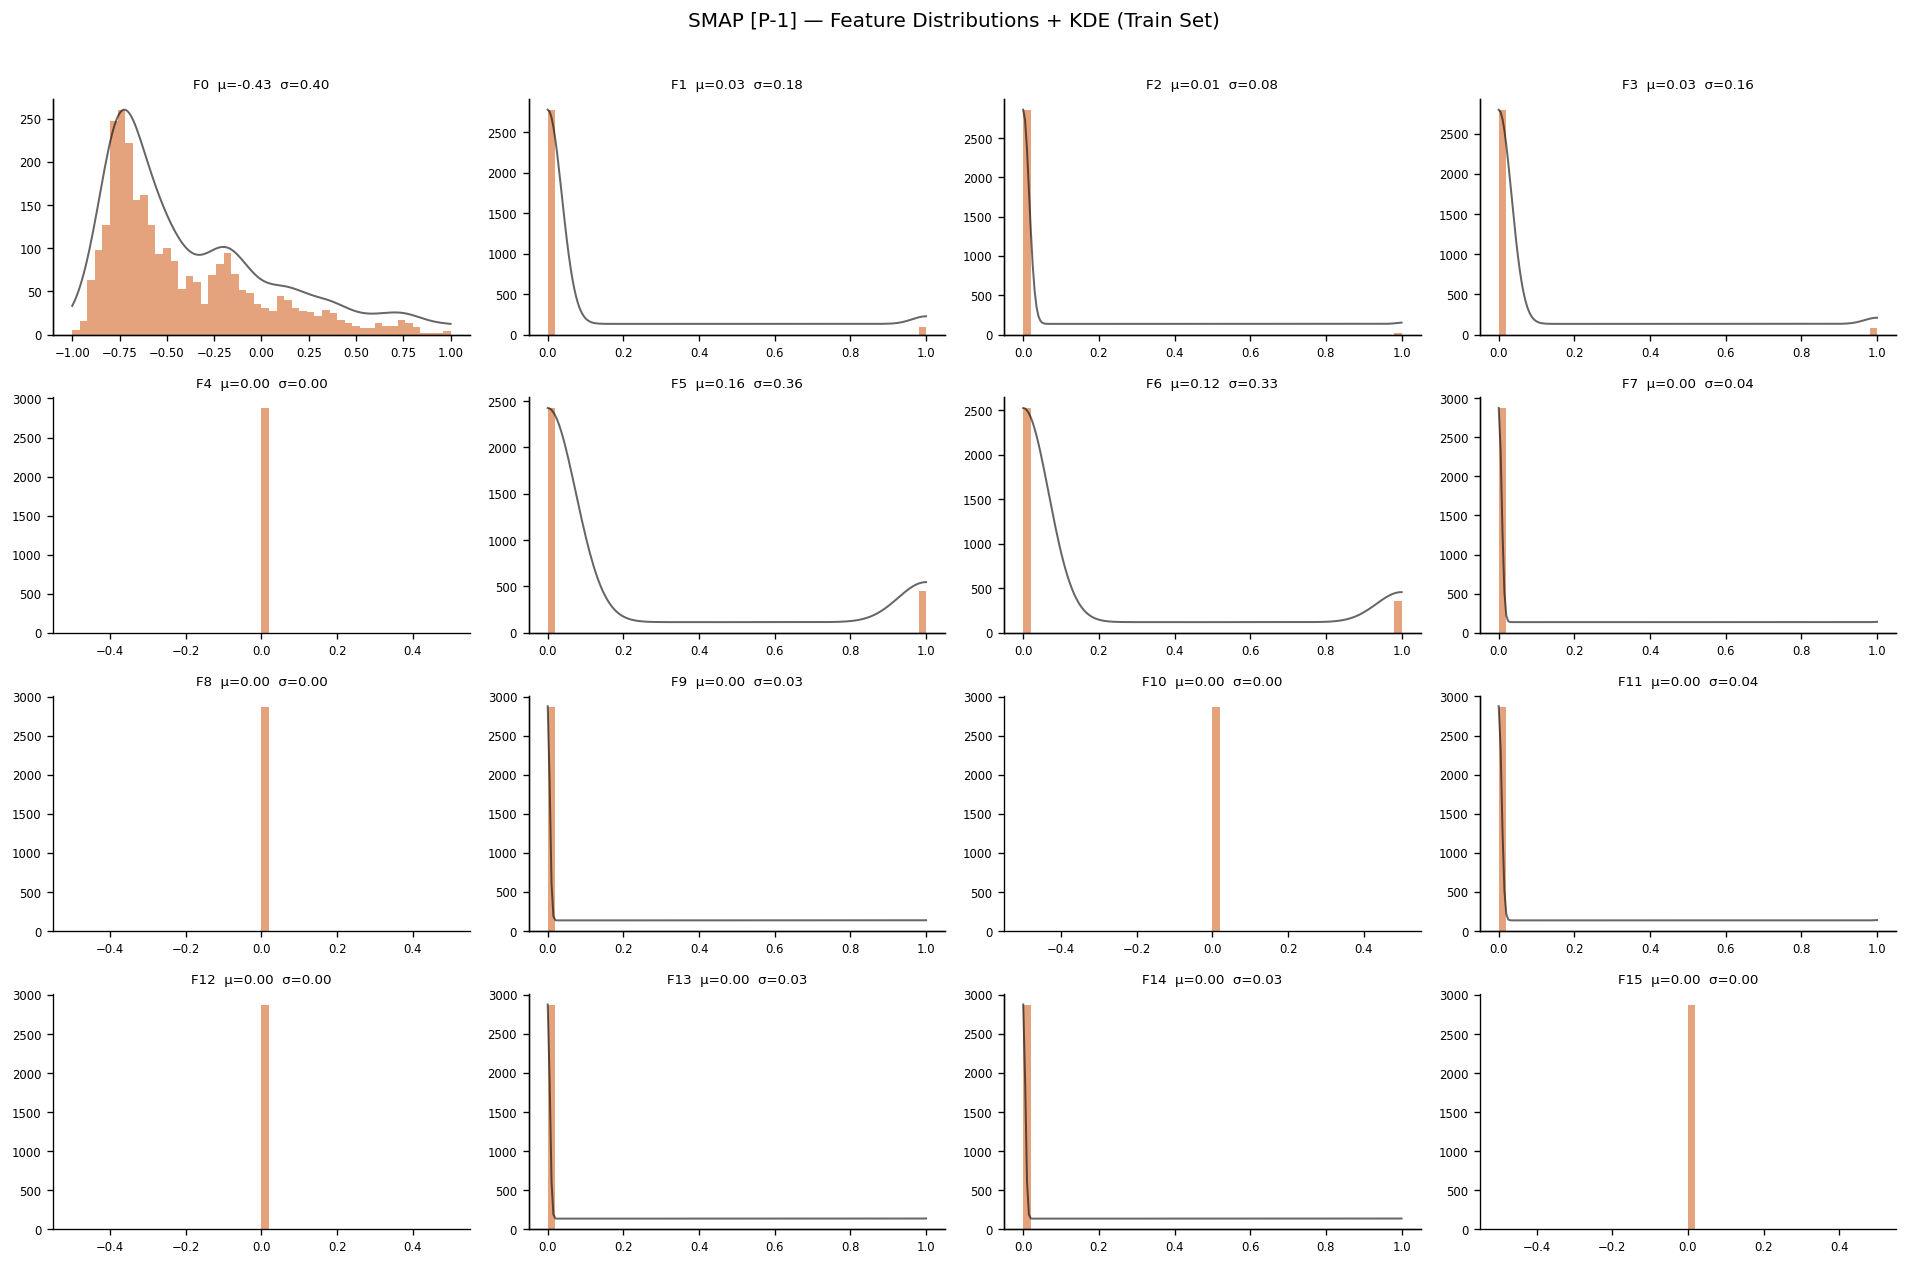

In [18]:
def plot_distributions(arr, chan, name, color, max_feat=16):
    if arr.ndim == 1: arr = arr.reshape(-1, 1)
    n = min(arr.shape[1], max_feat)
    c = 4; r = (n + c - 1) // c
    fig, axes = plt.subplots(r, c, figsize=(16, r * 2.6))
    axes = axes.flatten()

    for i in range(n):
        x = arr[:, i]
        ax = axes[i]
        ax.hist(x, bins=50, color=color, alpha=0.75, edgecolor='none')
        # Overlay KDE
        from scipy.stats import gaussian_kde
        if x.std() > 1e-9:
            kde_x = np.linspace(x.min(), x.max(), 200)
            kde_y = gaussian_kde(x)(kde_x)
            ax2   = ax.twinx()
            ax2.plot(kde_x, kde_y, color='black', linewidth=1.2, alpha=0.6)
            ax2.set_yticks([])
        ax.set_title(f"F{i}  μ={x.mean():.2f}  σ={x.std():.2f}", fontsize=8)
        ax.tick_params(labelsize=7)

    for j in range(n, len(axes)): axes[j].set_visible(False)
    fig.suptitle(f"{name} [{chan}] — Feature Distributions + KDE (Train Set)", fontsize=12, y=1.01)
    plt.tight_layout(); plt.show()

plot_distributions(msl_train[sample_msl],   sample_msl,  "MSL",  PALETTE['MSL'])
plot_distributions(smap_train[sample_smap], sample_smap, "SMAP", PALETTE['SMAP'])


> **Observation:** Many features show **non-Gaussian, multi-modal, or heavily skewed** distributions
> — typical of telemetry data operating across distinct modes.
>
> **Why MinMax over StandardScaler:**
> - MinMax is **distribution-agnostic** and produces bounded [0,1] output regardless of distribution shape
> - StandardScaler assumes approximate Gaussianity — poor fit for multi-modal telemetry
> - MEMTO's sigmoid/softmax activations are sensitive to extreme input values; MinMax prevents this


<a id='14'></a>
## 14. Feature Correlation Heatmap

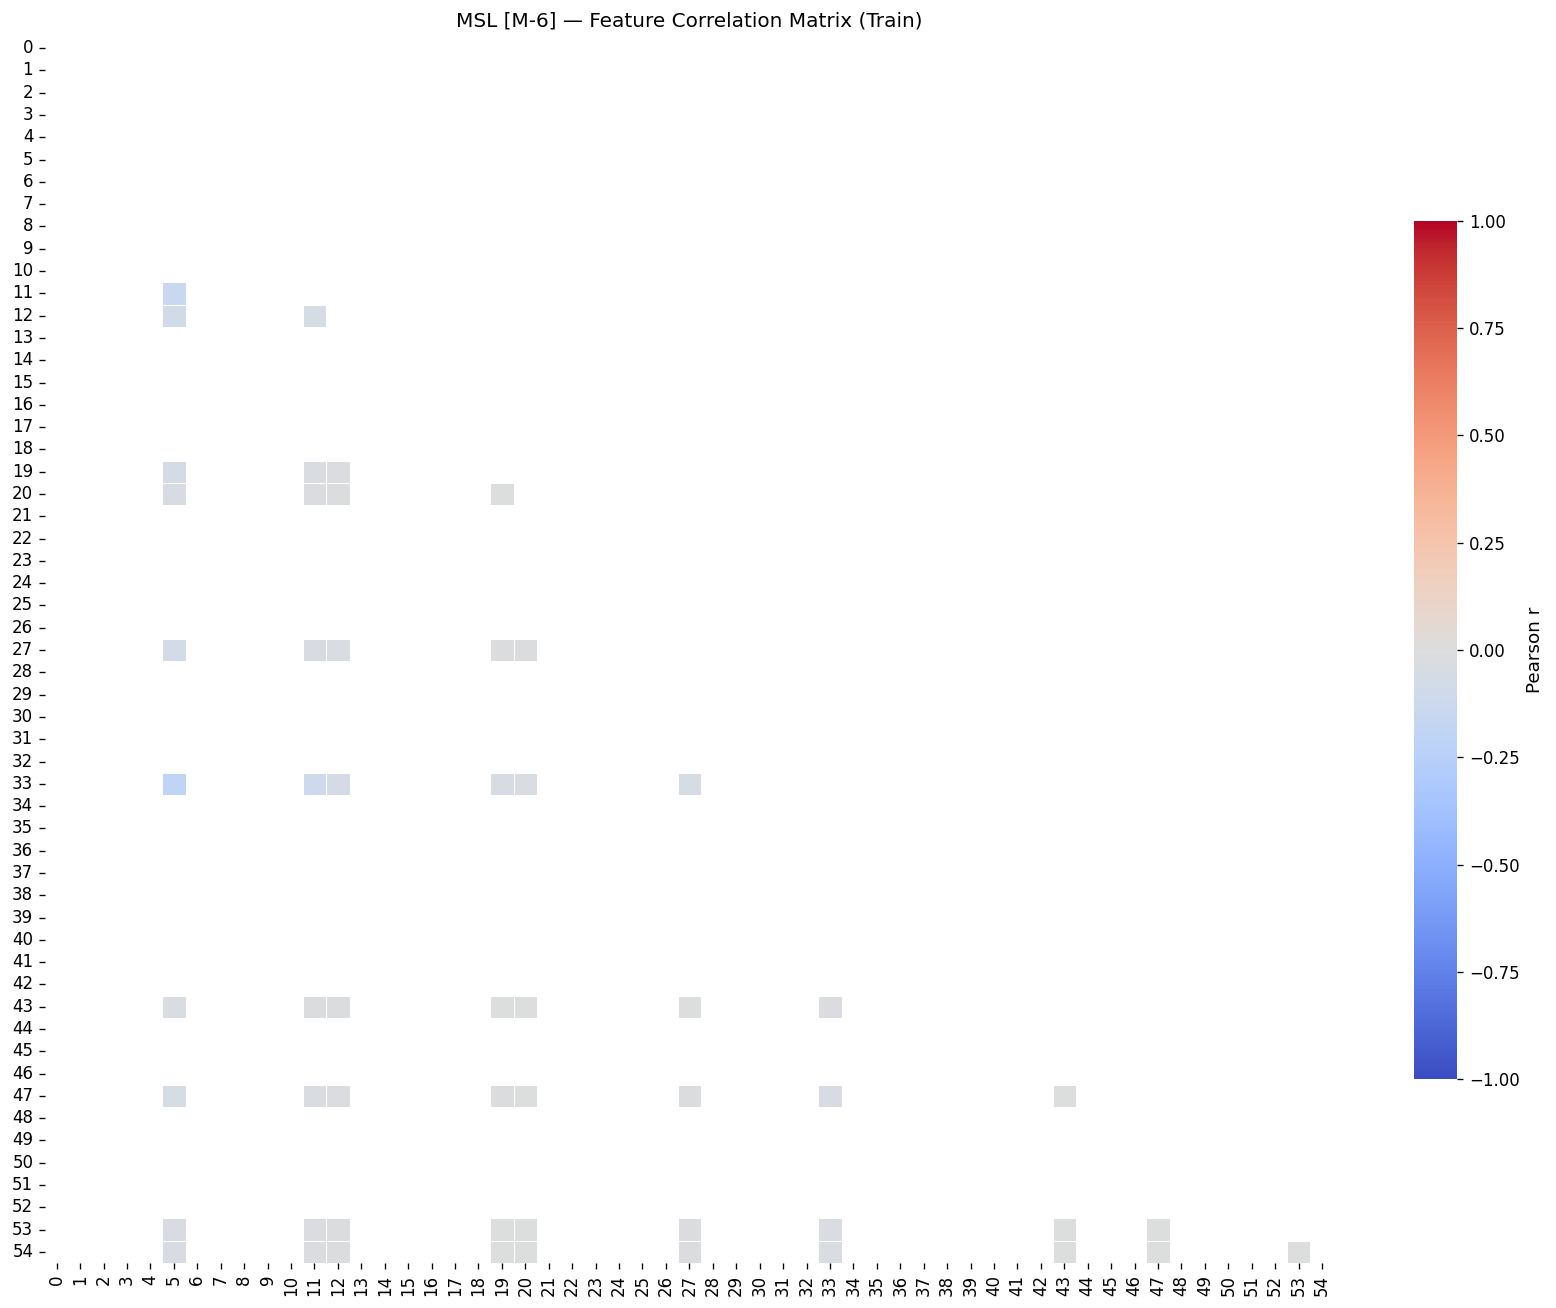

  Strong positive correlations (r > 0.7):  0 feature pairs
  Strong negative correlations (r < -0.7): 0 feature pairs


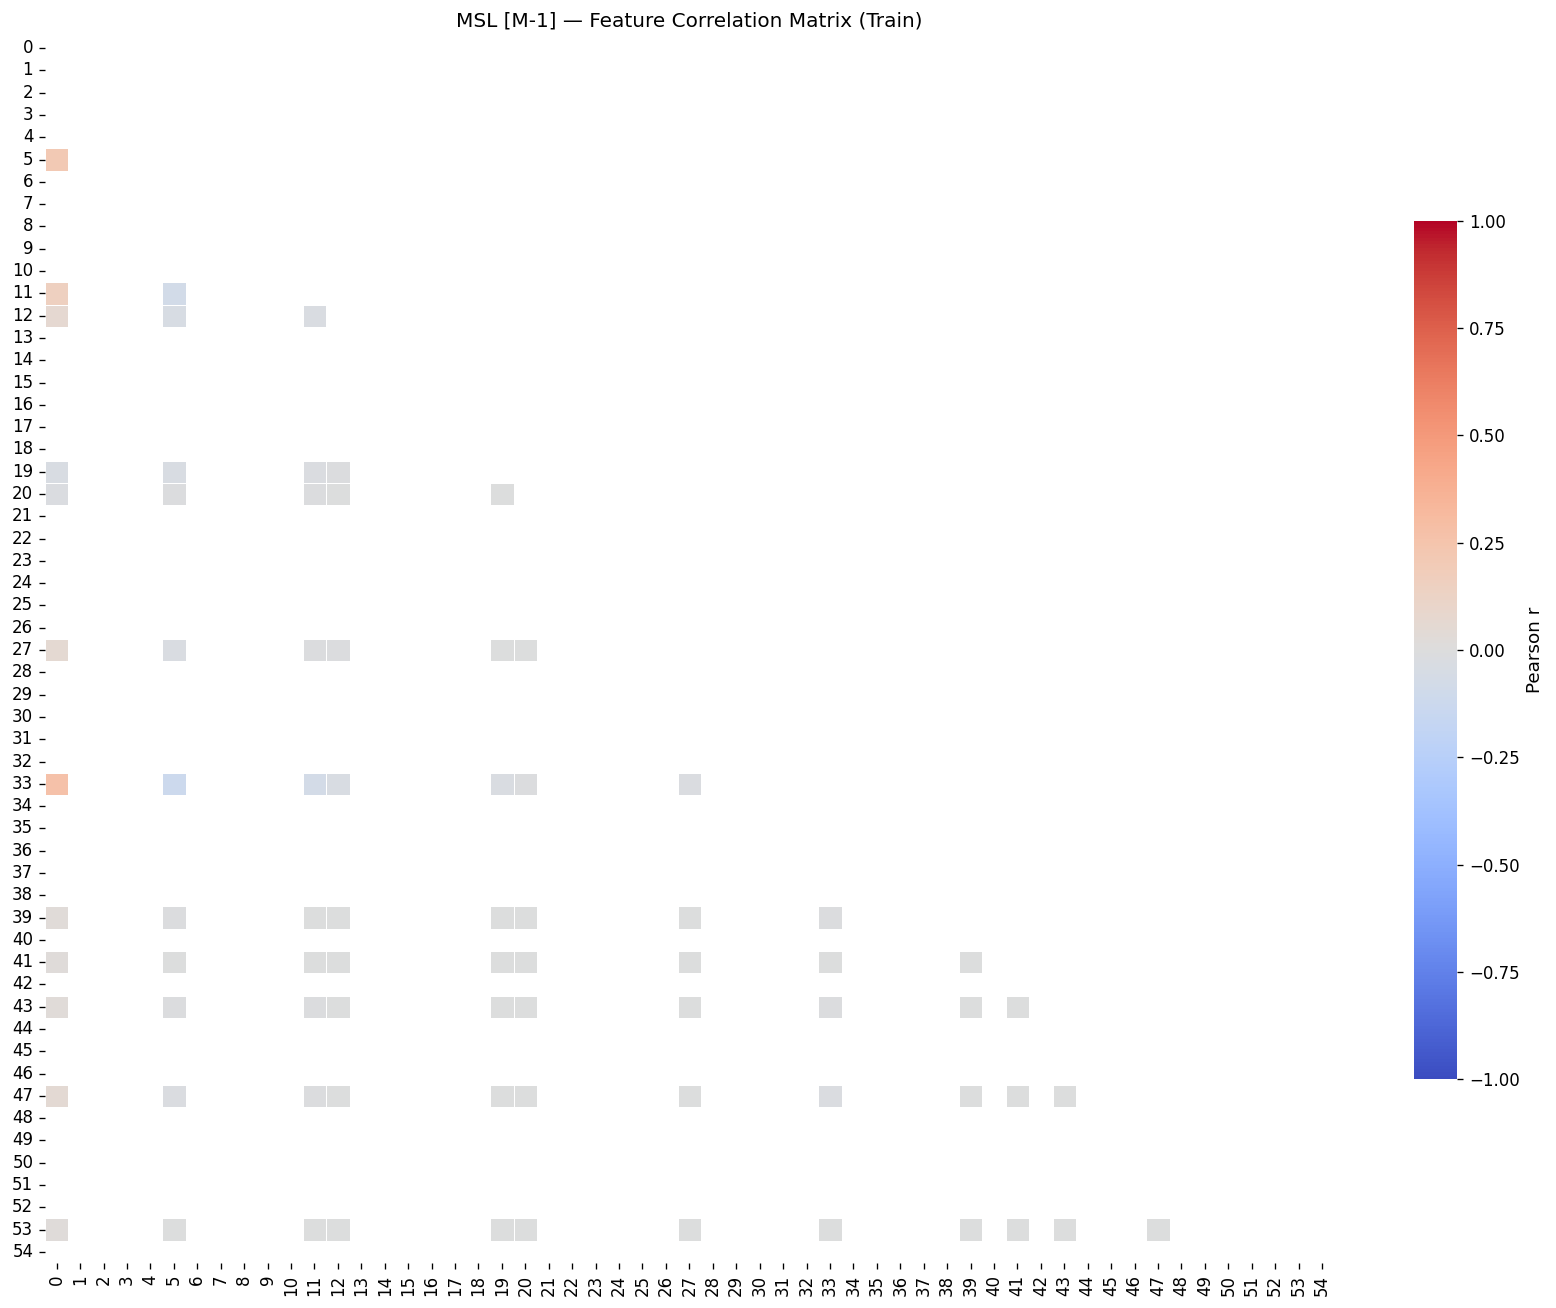

  Strong positive correlations (r > 0.7):  0 feature pairs
  Strong negative correlations (r < -0.7): 0 feature pairs


In [19]:
def plot_correlation(arr, chan, name):
    if arr.ndim == 1 or arr.shape[1] < 2:
        print(f"  Skipping {chan} — univariate channel."); return
    corr = pd.DataFrame(arr).corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig_size = (min(14, corr.shape[0] * 0.55 + 2), min(11, corr.shape[0] * 0.45 + 2))
    fig, ax = plt.subplots(figsize=fig_size)
    sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                annot=corr.shape[0] <= 20, fmt='.2f', linewidths=0.4, ax=ax,
                cbar_kws={'shrink': 0.7, 'label': 'Pearson r'})
    ax.set_title(f"{name} [{chan}] — Feature Correlation Matrix (Train)", fontsize=12)
    plt.tight_layout(); plt.show()

    high_pos = int(((corr > 0.7)  & ~mask).sum().sum()) // 2
    high_neg = int(((corr < -0.7) & ~mask).sum().sum()) // 2
    print(f"  Strong positive correlations (r > 0.7):  {high_pos} feature pairs")
    print(f"  Strong negative correlations (r < -0.7): {high_neg} feature pairs")

plot_correlation(msl_train[sample_msl], sample_msl, "MSL")

# Try another MSL channel with different feature structure
if len(msl_labels) > 1:
    chan2 = msl_labels.iloc[1]['chan_id']
    plot_correlation(msl_train[chan2], chan2, "MSL")


> **Observation:** High inter-feature correlation indicates **redundant information** across features.
> MEMTO's multi-head attention *can* learn to down-weight redundant features, but highly correlated
> feature clusters may reduce the effective diversity of memory slot prototypes.
> Consider PCA analysis (not required for MEMTO but useful for understanding the data manifold).


<a id='15'></a>
## 15. Autocorrelation (ACF) Analysis — Window Size Justification

ACF measures how much a signal correlates with its own lagged version.
**Strong ACF at large lags** proves the signal has temporal structure → justifies window-based detection over point-wise methods.


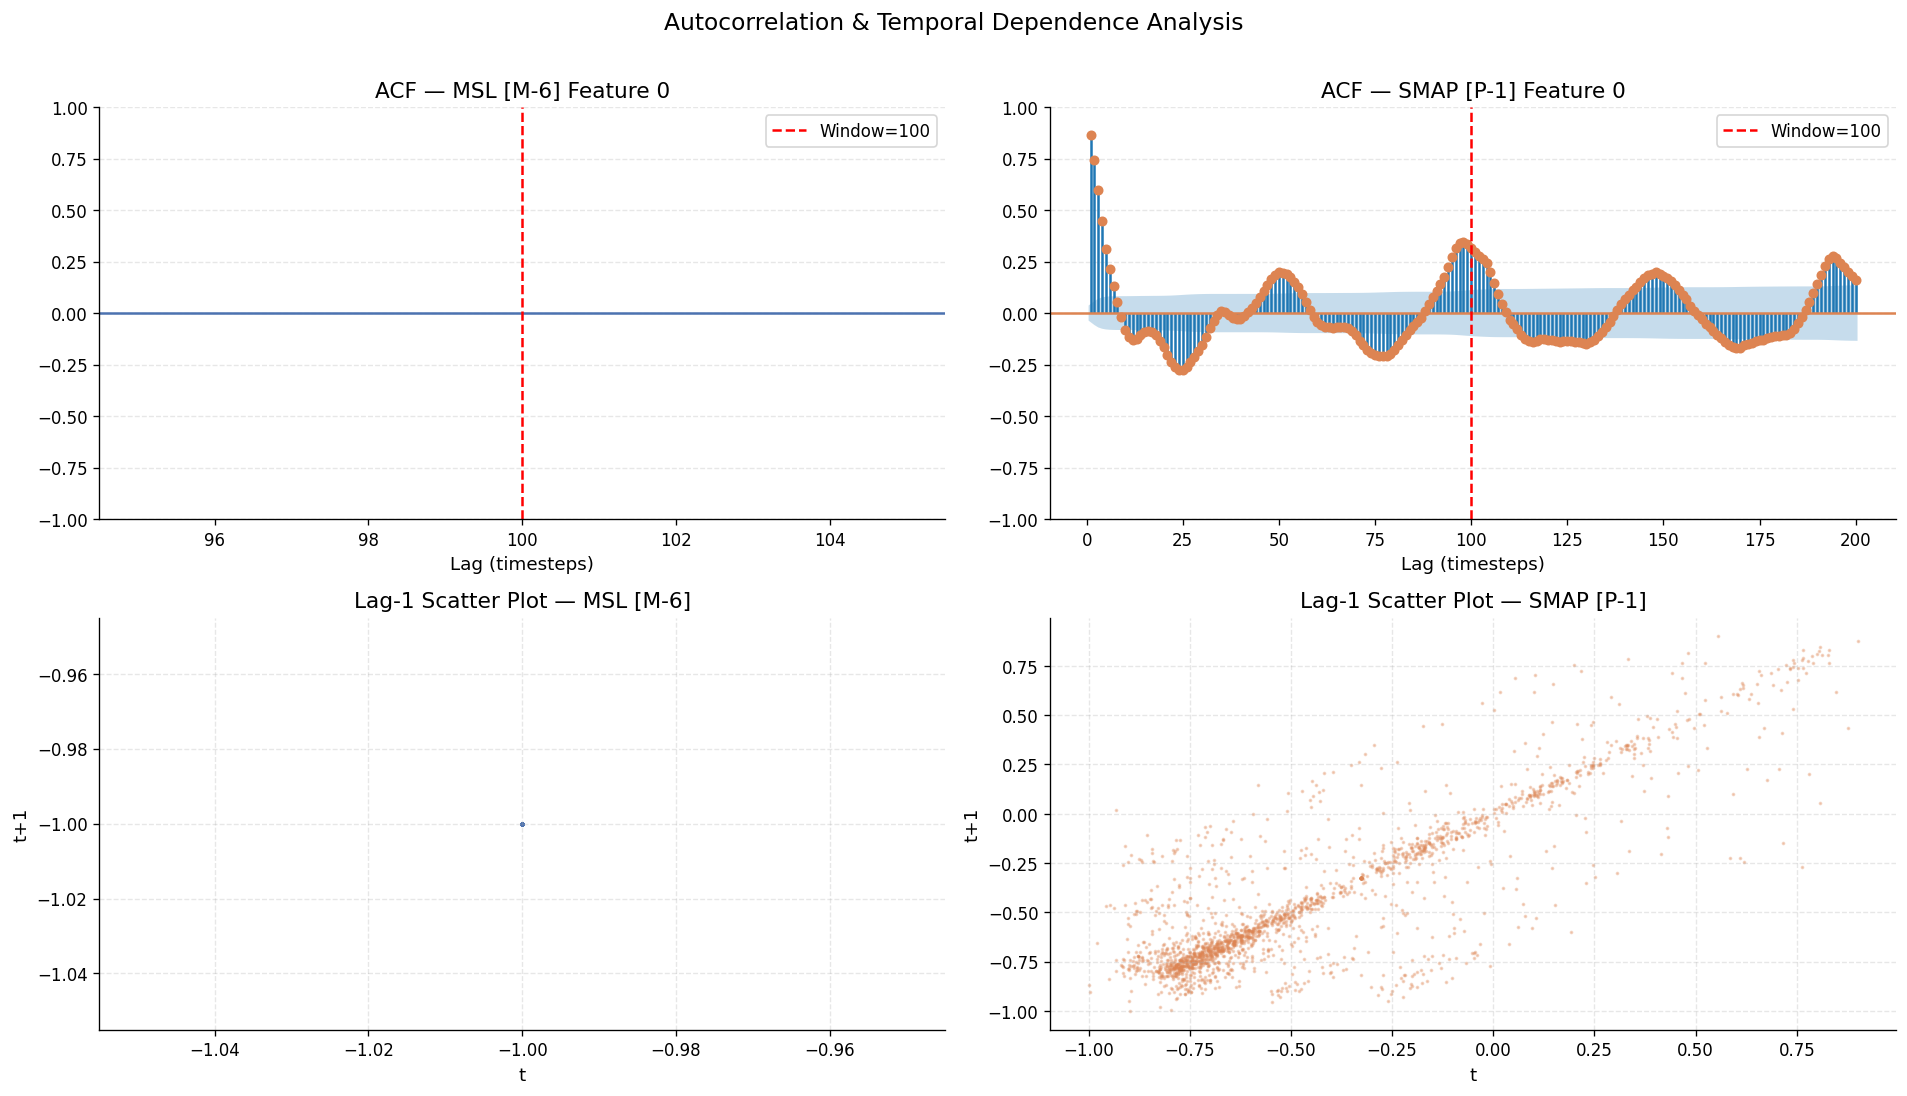

In [20]:
def plot_acf_comparison(msl_arr, smap_arr, msl_chan, smap_chan, lags=200, feat=0):
    msl_sig  = msl_arr[:,  feat] if msl_arr.ndim  > 1 else msl_arr
    smap_sig = smap_arr[:, feat] if smap_arr.ndim > 1 else smap_arr

    fig, axes = plt.subplots(2, 2, figsize=(16, 9))

    # ACF plots
    plot_acf(msl_sig[:5000],  lags=lags, ax=axes[0, 0],
             color=PALETTE['MSL'], alpha=0.05, zero=False,
             title=f"ACF — MSL [{msl_chan}] Feature {feat}")
    axes[0, 0].axvline(100, color='red', linestyle='--', linewidth=1.5, label='Window=100')
    axes[0, 0].legend(); axes[0, 0].set_xlabel("Lag (timesteps)")
    axes[0, 0].grid(axis='y')

    plot_acf(smap_sig[:5000], lags=lags, ax=axes[0, 1],
             color=PALETTE['SMAP'], alpha=0.05, zero=False,
             title=f"ACF — SMAP [{smap_chan}] Feature {feat}")
    axes[0, 1].axvline(100, color='red', linestyle='--', linewidth=1.5, label='Window=100')
    axes[0, 1].legend(); axes[0, 1].set_xlabel("Lag (timesteps)")
    axes[0, 1].grid(axis='y')

    # Lag scatter (lag-1 vs lag-0 plot)
    for ax, sig, name, color in [
            (axes[1, 0], msl_sig[:2000],  f"MSL [{msl_chan}]",  PALETTE['MSL']),
            (axes[1, 1], smap_sig[:2000], f"SMAP [{smap_chan}]", PALETTE['SMAP'])]:
        ax.scatter(sig[:-1], sig[1:], s=1.5, alpha=0.3, color=color)
        ax.set_title(f"Lag-1 Scatter Plot — {name}")
        ax.set_xlabel("t"); ax.set_ylabel("t+1")
        ax.grid()

    plt.suptitle("Autocorrelation & Temporal Dependence Analysis", fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()

plot_acf_comparison(msl_train[sample_msl], smap_train[sample_smap],
                    sample_msl, sample_smap)


> **Observations:**
> - Significant ACF up to high lags confirms **strong temporal structure** in telemetry signals
> - This justifies MEMTO's Transformer architecture over point-anomaly classifiers
> - ACF typically decays substantially by lag ~100 → patterns within 100 timesteps are **temporally coherent units**
>   → this is the formal justification for `window_size=100`
> - The lag-1 scatter plot (x=t, y=t+1) showing a tight linear structure confirms high autocorrelation
> - Periodic ACF spikes indicate **cyclical operating modes** — MEMTO's memory slots can store these as distinct prototypes


<a id='16'></a>
## 16. Rolling Statistics & Non-Stationarity

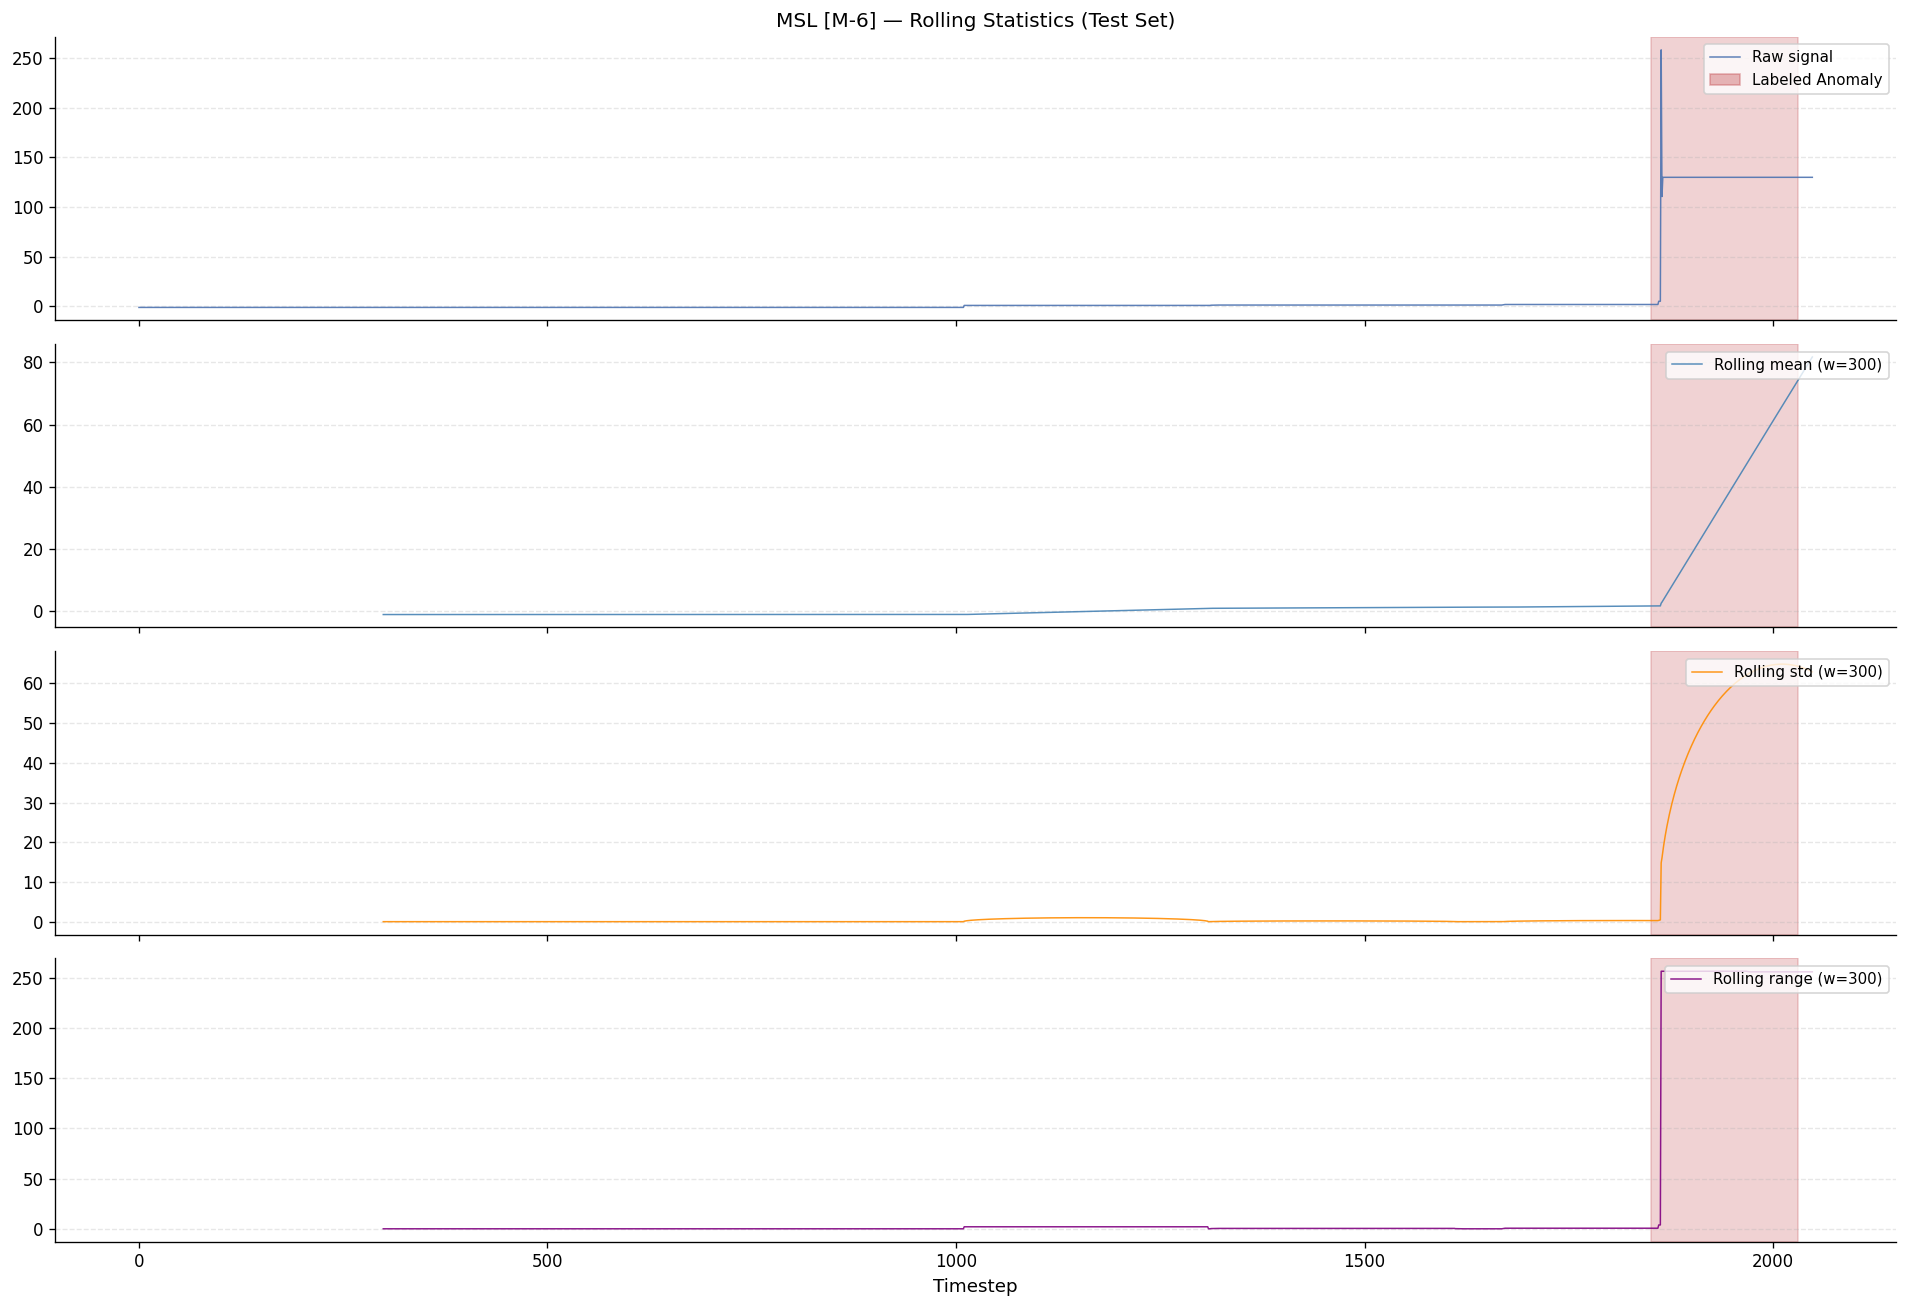

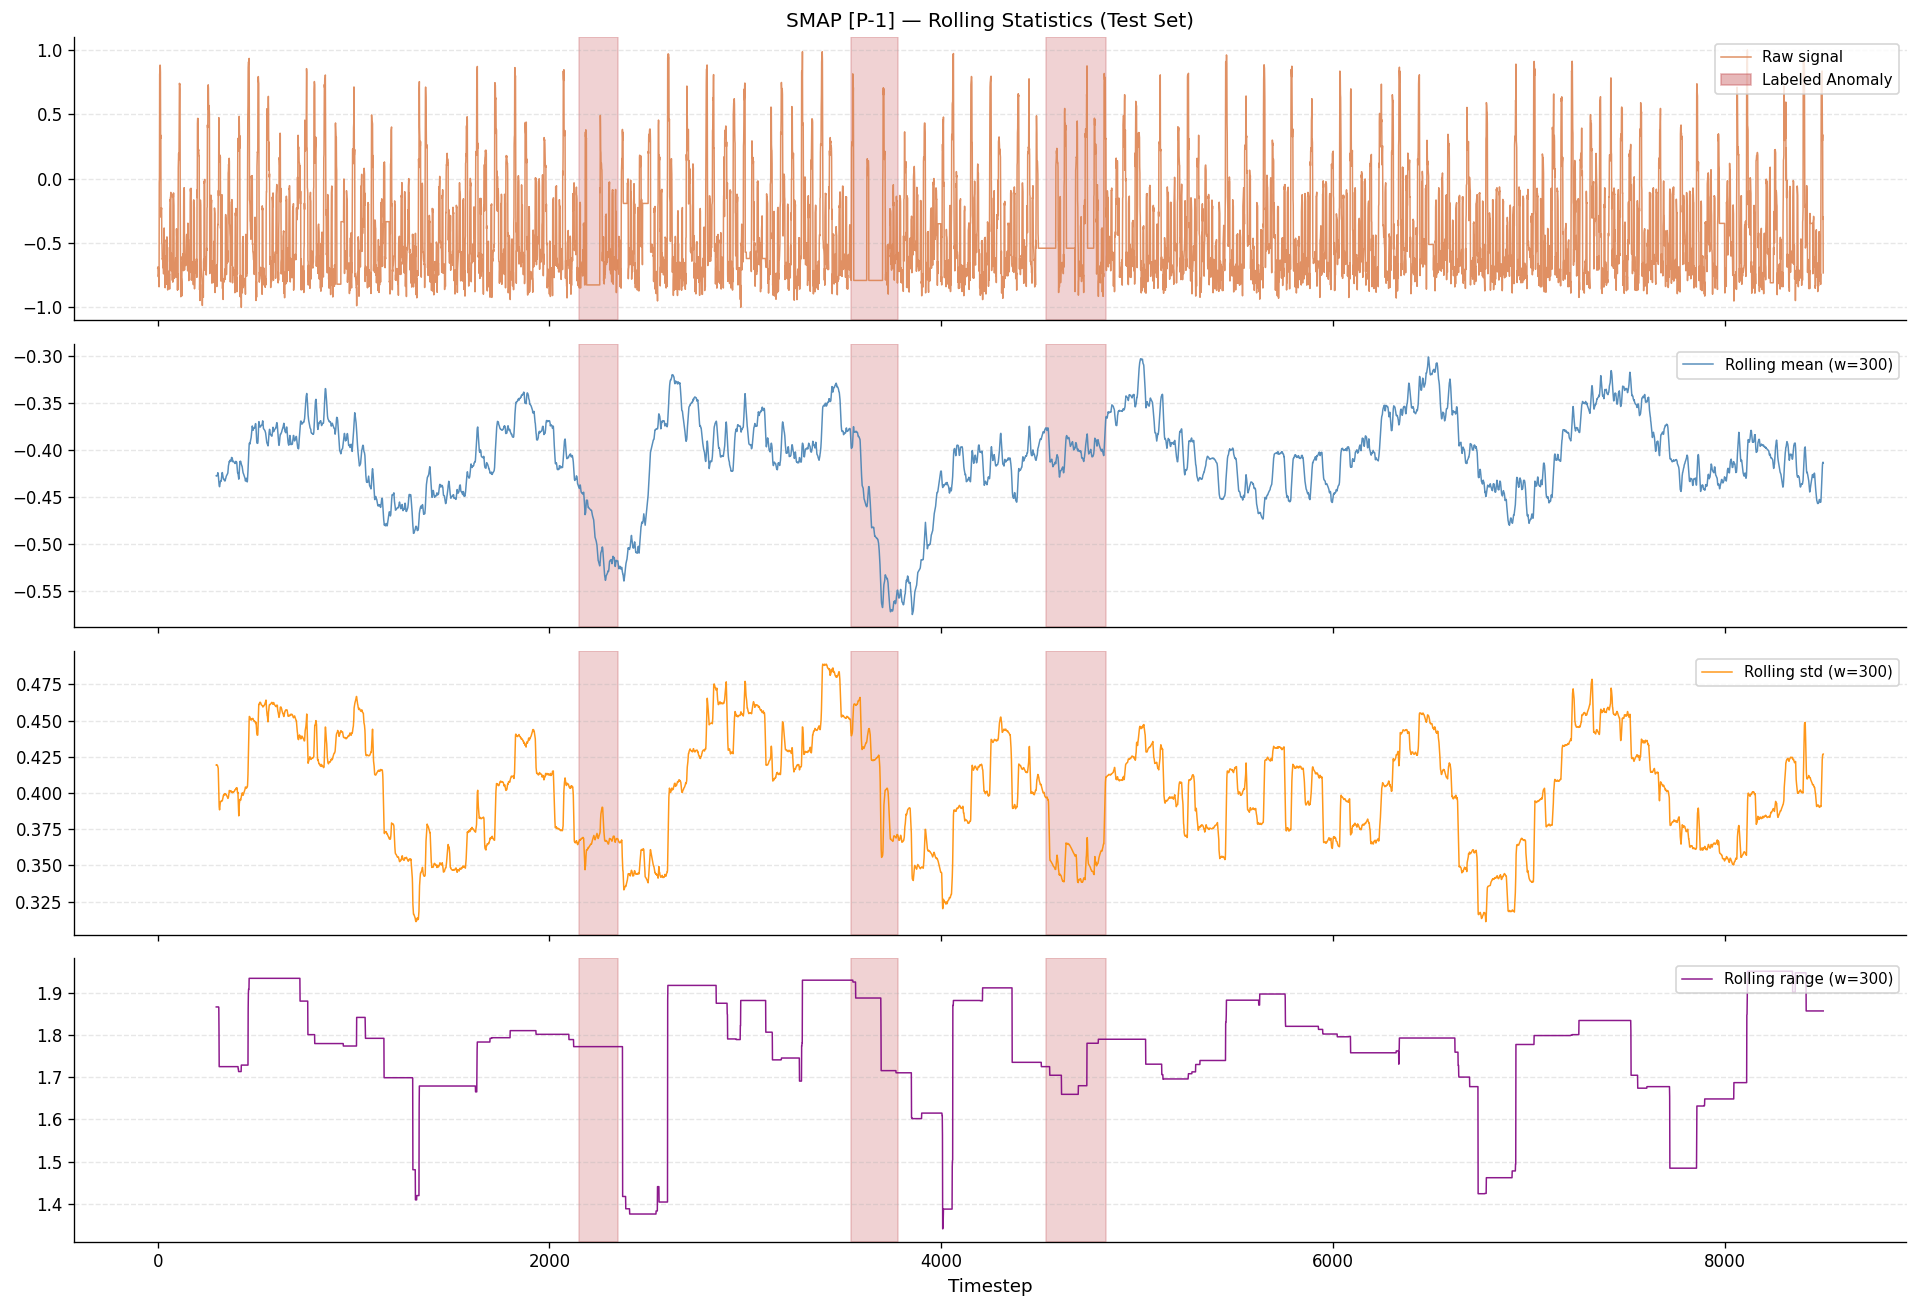

In [21]:
def plot_rolling(test_arr, label_row, chan, name, color, feat=0, window=300):
    sig  = test_arr[:, feat] if test_arr.ndim > 1 else test_arr
    seqs = parse_seqs(label_row['anomaly_sequences'].values[0])
    s    = pd.Series(sig.astype(float))

    fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True)

    plot_data = [
        (sig,                        color,       'Raw signal'),
        (s.rolling(window).mean(),   'steelblue', f'Rolling mean (w={window})'),
        (s.rolling(window).std(),    'darkorange', f'Rolling std (w={window})'),
        (s.rolling(window).max() - s.rolling(window).min(), 'purple', f'Rolling range (w={window})'),
    ]

    for ax, (data, c, label) in zip(axes, plot_data):
        ax.plot(data, color=c, linewidth=0.9, alpha=0.9, label=label)
        for start, end in seqs:
            ax.axvspan(start, end, color=PALETTE['anomaly'], alpha=0.25)
        ax.legend(loc='upper right', fontsize=9); ax.grid(axis='y')

    axes[0].set_title(f"{name} [{chan}] — Rolling Statistics (Test Set)", fontsize=12)
    axes[-1].set_xlabel("Timestep")

    # Add anomaly legend
    patch = mpatches.Patch(color=PALETTE['anomaly'], alpha=0.4, label='Labeled Anomaly')
    axes[0].legend(handles=[axes[0].get_lines()[0], patch], loc='upper right', fontsize=9)

    plt.tight_layout(); plt.show()

plot_rolling(msl_test[sample_msl],
             msl_labels[msl_labels['chan_id'] == sample_msl],   sample_msl,  "MSL",  PALETTE['MSL'])
plot_rolling(smap_test[sample_smap],
             smap_labels[smap_labels['chan_id'] == sample_smap], sample_smap, "SMAP", PALETTE['SMAP'])


> **Observations:**
> - **Rolling std spikes** aligned with anomaly windows confirm anomalies = increased local variance
> - **Rolling mean drift** shows non-stationary baselines → normalization must be done per-channel
>   using train statistics (not global statistics)
> - **Rolling range** captures both mean shifts AND variance increases — a stronger signal for detection
> - This motivates fitting the MinMax scaler on **train data only** and applying to test — avoiding data leakage


<a id='17'></a>
## 17. Stationarity Test (Augmented Dickey-Fuller)

In [22]:
def run_adf(signal, chan, name, feat_idx=0):
    sig  = signal[:, feat_idx] if signal.ndim > 1 else signal
    # Use a subset for speed
    result = adfuller(sig[:5000], autolag='AIC')
    stat, p_val, _, _, crit, _ = result
    stationary = "✅ Stationary" if p_val < 0.05 else "⚠️ Non-stationary"
    print(f"  {name} [{chan}] F{feat_idx}: ADF stat={stat:.4f}, p={p_val:.4f}, "
          f"5%crit={crit['5%']:.4f}  →  {stationary}")
    return p_val

print("Augmented Dickey-Fuller Test (H0: unit root exists = non-stationary):")
print("  p < 0.05 → reject H0 → stationary\n")

print("MSL channels (feature 0):")
for _, row in msl_labels.head(5).iterrows():
    chan = row['chan_id']
    if chan in msl_train:
        run_adf(msl_train[chan], chan, "MSL", feat_idx=0)

print("\nSMAP channels (feature 0):")
for _, row in smap_labels.head(5).iterrows():
    chan = row['chan_id']
    if chan in smap_train:
        run_adf(smap_train[chan], chan, "SMAP", feat_idx=0)


Augmented Dickey-Fuller Test (H0: unit root exists = non-stationary):
  p < 0.05 → reject H0 → stationary

MSL channels (feature 0):


ValueError: Invalid input, x is constant

> **Interpretation:**
> - **Stationary (p < 0.05):** Mean and variance are stable over time — standard normalization applies directly
> - **Non-stationary (p ≥ 0.05):** Signal has trends or changing variance — MinMax normalization helps but
>   MEMTO may benefit from additional detrending (not in the original paper, but worth noting)
> - The ADF test results inform whether per-channel or global normalization is more appropriate


<a id='18'></a>
## 18. Normalization — Justification & Before/After

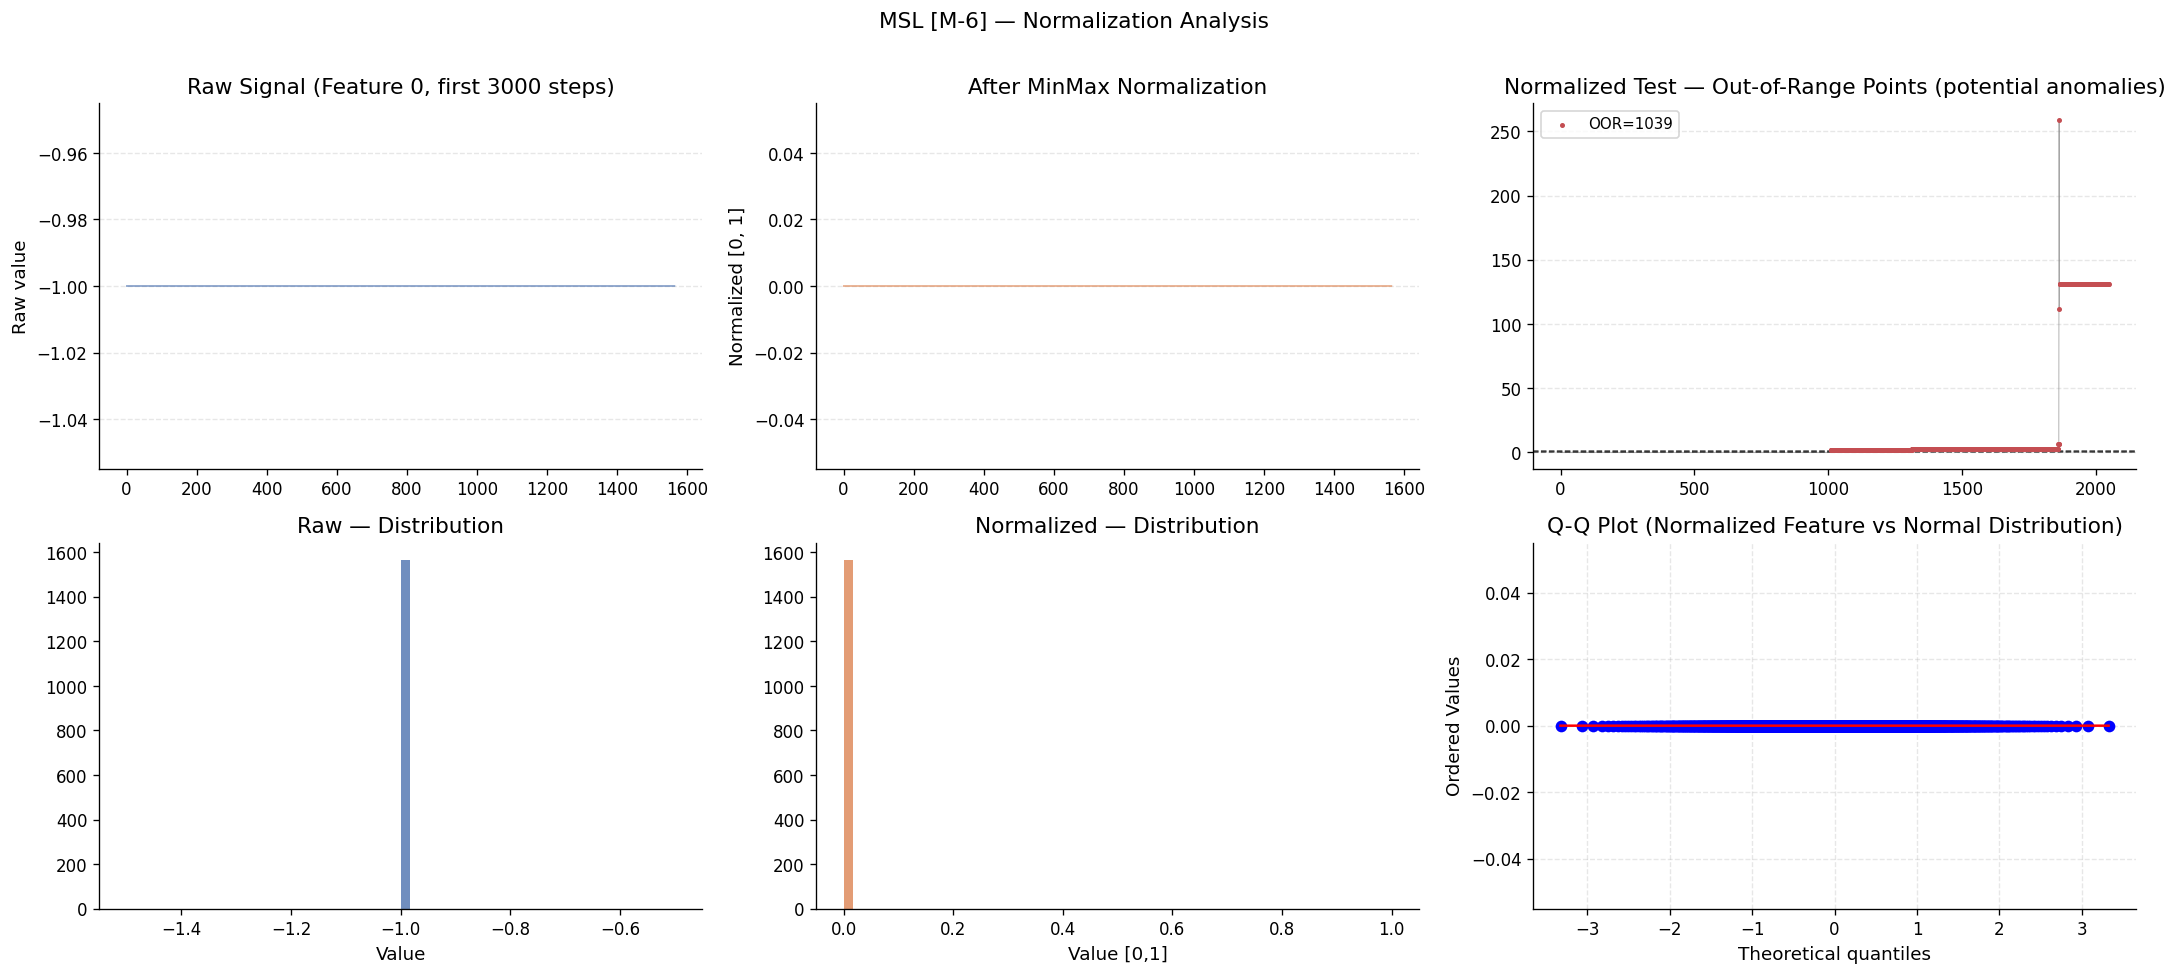

MSL Sample — Feature 0 Statistics:
  Before: min=-1.0000, max=-1.0000, mean=-1.0000, std=0.0000
  After : min=0.0000, max=0.0000, mean=0.0000, std=0.0000
  Test OOR points: 1039 (50.71%) — potential anomaly indicators


In [23]:
def normalize_channel(train_arr, test_arr, method='minmax'):
    squeeze = (train_arr.ndim == 1)
    if squeeze:
        train_arr = train_arr.reshape(-1, 1)
        test_arr  = test_arr.reshape(-1, 1)
    scaler     = MinMaxScaler() if method == 'minmax' else StandardScaler()
    train_norm = scaler.fit_transform(train_arr)
    test_norm  = scaler.transform(test_arr)
    if squeeze:
        train_norm = train_norm.squeeze()
        test_norm  = test_norm.squeeze()
    return train_norm, test_norm, scaler

# ── Before/After visualization ──
raw_train = msl_train[sample_msl]
raw_feat  = raw_train[:, 0] if raw_train.ndim > 1 else raw_train

norm_train, norm_test, _ = normalize_channel(msl_train[sample_msl], msl_test[sample_msl])
norm_feat = norm_train[:, 0] if norm_train.ndim > 1 else norm_train

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

# Time-series before/after
axes[0, 0].plot(raw_feat[:3000],  color=PALETTE['MSL'],  linewidth=0.7)
axes[0, 0].set_title("Raw Signal (Feature 0, first 3000 steps)")
axes[0, 0].set_ylabel("Raw value"); axes[0, 0].grid(axis='y')

axes[0, 1].plot(norm_feat[:3000], color=PALETTE['SMAP'], linewidth=0.7)
axes[0, 1].set_title("After MinMax Normalization")
axes[0, 1].set_ylabel("Normalized [0, 1]"); axes[0, 1].grid(axis='y')

# Check test set out-of-range (indicator of anomaly)
norm_test_feat = norm_test[:, 0] if norm_test.ndim > 1 else norm_test
oor_mask = (norm_test_feat < 0) | (norm_test_feat > 1)
axes[0, 2].plot(norm_test_feat, color='gray', linewidth=0.5, alpha=0.7)
axes[0, 2].scatter(np.where(oor_mask)[0], norm_test_feat[oor_mask],
                   s=4, color=PALETTE['anomaly'], zorder=5, label=f'OOR={oor_mask.sum()}')
axes[0, 2].axhline(0, color='black', linestyle='--', linewidth=0.9, alpha=0.7)
axes[0, 2].axhline(1, color='black', linestyle='--', linewidth=0.9, alpha=0.7)
axes[0, 2].set_title("Normalized Test — Out-of-Range Points (potential anomalies)")
axes[0, 2].legend(fontsize=9); axes[0, 2].grid(axis='y')

# Distributions
axes[1, 0].hist(raw_feat,  bins=60, color=PALETTE['MSL'],  alpha=0.8, edgecolor='none')
axes[1, 0].set_title("Raw — Distribution"); axes[1, 0].set_xlabel("Value")

axes[1, 1].hist(norm_feat, bins=60, color=PALETTE['SMAP'], alpha=0.8, edgecolor='none')
axes[1, 1].set_title("Normalized — Distribution"); axes[1, 1].set_xlabel("Value [0,1]")
axes[1, 1].set_xlim(-0.05, 1.05)

# Q-Q plot (normality check)
from scipy.stats import probplot
probplot(norm_feat, plot=axes[1, 2])
axes[1, 2].set_title("Q-Q Plot (Normalized Feature vs Normal Distribution)")
axes[1, 2].grid()

plt.suptitle(f"MSL [{sample_msl}] — Normalization Analysis", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print("MSL Sample — Feature 0 Statistics:")
print(f"  Before: min={raw_feat.min():.4f}, max={raw_feat.max():.4f}, "
      f"mean={raw_feat.mean():.4f}, std={raw_feat.std():.4f}")
print(f"  After : min={norm_feat.min():.4f}, max={norm_feat.max():.4f}, "
      f"mean={norm_feat.mean():.4f}, std={norm_feat.std():.4f}")
print(f"  Test OOR points: {oor_mask.sum()} ({100*oor_mask.mean():.2f}%) — potential anomaly indicators")


> **Design Decisions:**
> - **Scaler fit on train only** — applying train statistics to test data prevents data leakage
> - **Out-of-range test values** (< 0 or > 1 after MinMax) occur when the test channel visits values
>   outside the train range — these are naturally flagged as anomalous by MEMTO's reconstruction
> - **Q-Q plot**: if the normalized distribution is close to the Q-Q line, transformer attention
>   weights will be well-conditioned; heavy tails suggest gradient clipping may be needed


<a id='19'></a>
## 19. Outlier Analysis — MinMax vs StandardScaler

In [ ]:
raw_2d = msl_train[sample_msl].reshape(-1, 1) if msl_train[sample_msl].ndim == 1 else msl_train[sample_msl]
feat   = raw_2d[:, 0]

mm_scaled = MinMaxScaler().fit_transform(raw_2d)[:, 0]
ss_scaled = StandardScaler().fit_transform(raw_2d)[:, 0]

# IQR outliers
q1, q3 = np.percentile(feat, 25), np.percentile(feat, 75)
iqr    = q3 - q1
outlier_mask = (feat < q1 - 1.5*iqr) | (feat > q3 + 1.5*iqr)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for col, (vals, title, color) in enumerate(zip(
        [feat,  mm_scaled,              ss_scaled],
        ['Raw', 'MinMax [0,1]',         'StandardScaler (z-score)'],
        [PALETTE['MSL'], PALETTE['SMAP'], PALETTE['val']])):
    # Histogram
    axes[0, col].hist(vals, bins=70, color=color, alpha=0.8, edgecolor='none')
    axes[0, col].set_title(f"{title}")
range: [{vals.min():.3f}, {vals.max():.3f}]")
    axes[0, col].set_xlabel("Value")
    axes[0, col].grid(axis='y')

    # Time-series with outliers
    axes[1, col].plot(vals[:3000], color=color, linewidth=0.5, alpha=0.7)
    om = outlier_mask[:3000]
    axes[1, col].scatter(np.where(om)[0], vals[:3000][om],
                         s=10, color='red', zorder=5, label=f'IQR outliers')
    axes[1, col].legend(fontsize=9); axes[1, col].grid(axis='y')
    axes[1, col].set_title(f"{title} — Time Series + Outliers")

plt.suptitle(f"MSL [{sample_msl}] Feature 0 — Scaler Comparison", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print(f"IQR outliers: {outlier_mask.sum()} ({100*outlier_mask.mean():.2f}% of all points)")
print(f"StandardScaler max |z-score|: {abs(ss_scaled).max():.2f}")
print(f"MinMax test OOR (if test exceeds train range): "
      f"handled by scaler.transform() producing values outside [0,1]")


> **Why MinMax is preferred for MEMTO:**
> - StandardScaler with large z-scores produces extreme attention logits → gradient instability
> - MinMax keeps all train values in [0, 1] → stable early training gradients
> - Out-of-train-range test values naturally exceed [0, 1] — this is **desirable** as an anomaly signal


<a id='20'></a>
## 20. Sliding Window Design & MemoryError Fix

In [27]:
# Normalize all channels first
print("Normalizing MSL channels...")
msl_train_norm, msl_test_norm, msl_scalers = {}, {}, {}
for chan in msl_train:
    tr, te, sc = normalize_channel(msl_train[chan], msl_test.get(chan, msl_train[chan]))
    msl_train_norm[chan] = tr
    msl_test_norm[chan]  = te
    msl_scalers[chan]    = sc
print(f"  ✅ Normalized {len(msl_train_norm)} MSL channels")

print("Normalizing SMAP channels...")
smap_train_norm, smap_test_norm, smap_scalers = {}, {}, {}
for chan in smap_train:
    tr, te, sc = normalize_channel(smap_train[chan], smap_test.get(chan, smap_train[chan]))
    smap_train_norm[chan] = tr
    smap_test_norm[chan]  = te
    smap_scalers[chan]    = sc
print(f"  ✅ Normalized {len(smap_train_norm)} SMAP channels")


Normalizing MSL channels...
  ✅ Normalized 27 MSL channels
Normalizing SMAP channels...
  ✅ Normalized 54 SMAP channels


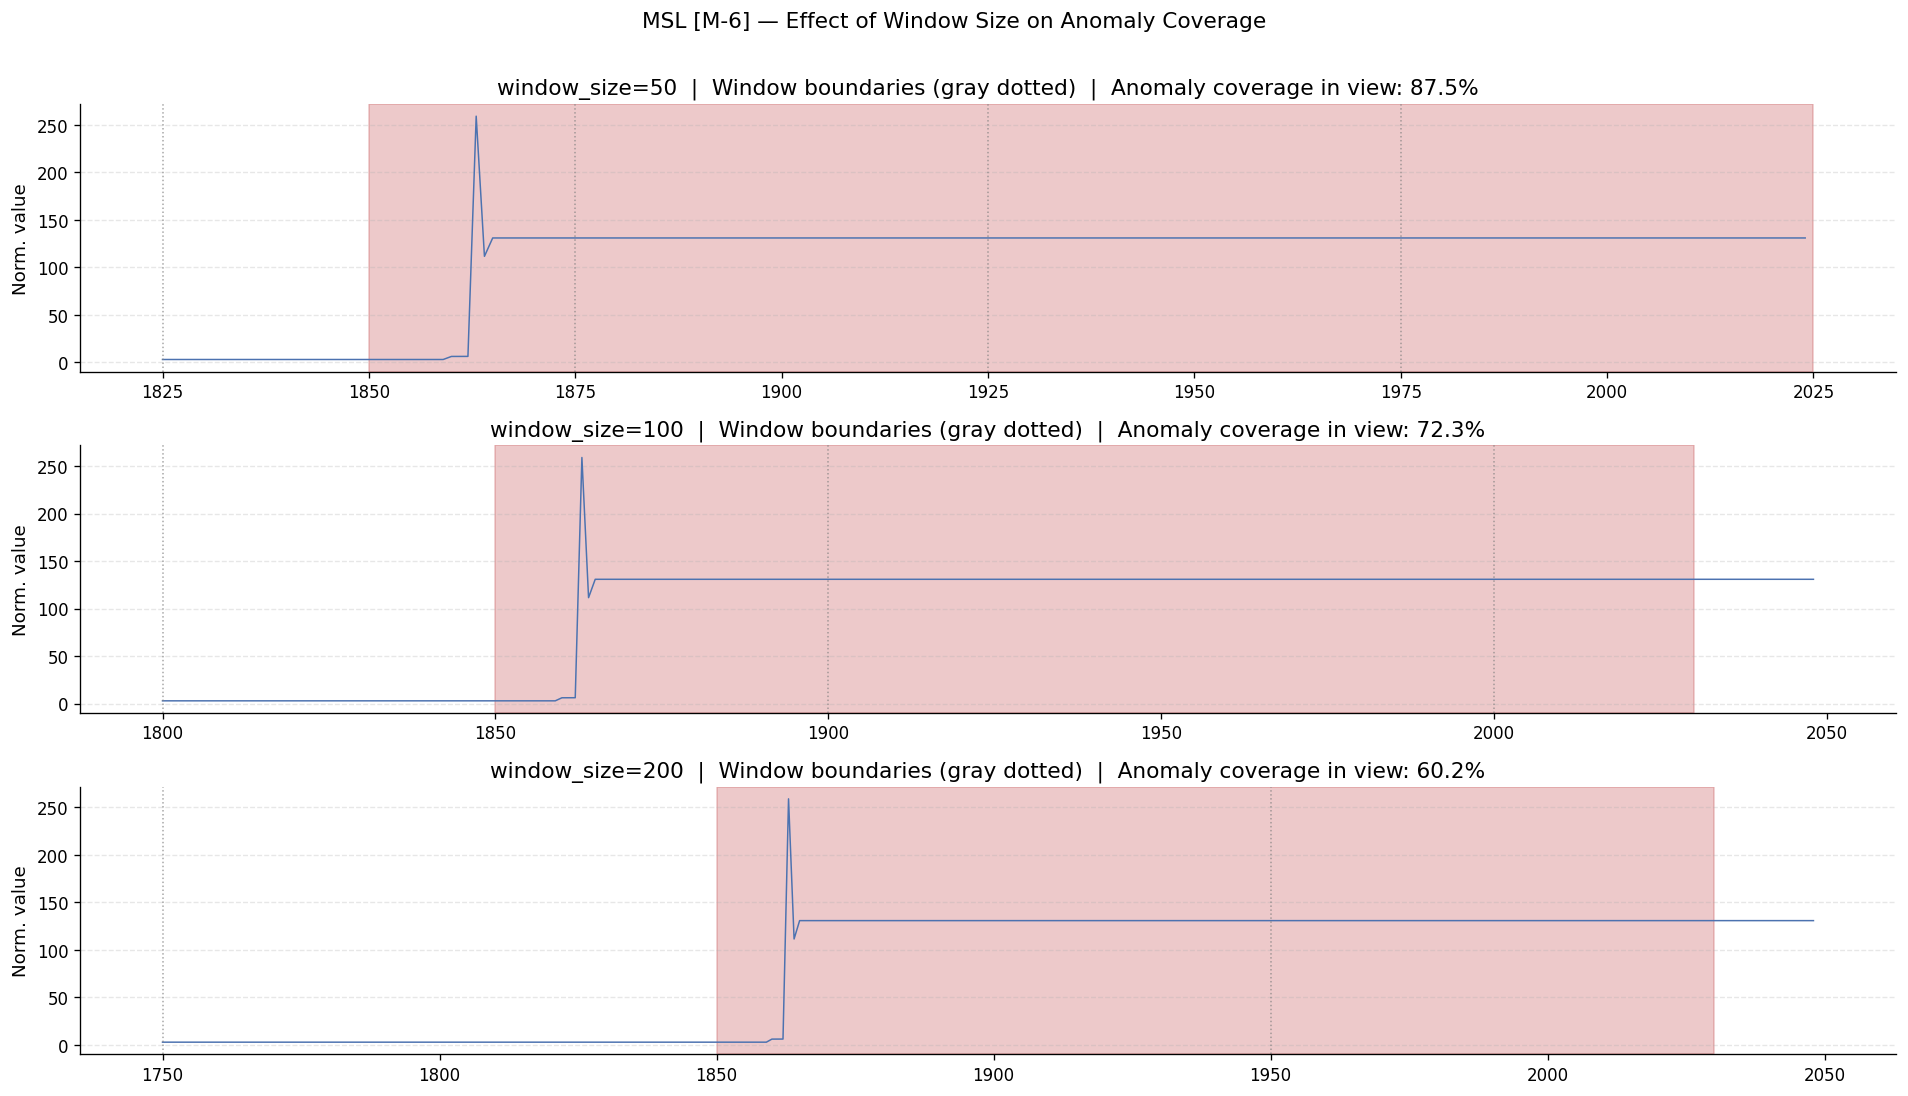

In [28]:
# Window size justification plot
test_arr = msl_test_norm[sample_msl]
sig      = test_arr[:, 0] if test_arr.ndim > 1 else test_arr
seqs     = parse_seqs(msl_labels[msl_labels['chan_id'] == sample_msl]['anomaly_sequences'].values[0])
first_start = seqs[0][0] if seqs else 300

window_sizes = [50, 100, 200]
fig, axes = plt.subplots(len(window_sizes), 1, figsize=(16, 9), sharex=False)

for ax, ws in zip(axes, window_sizes):
    start = max(0, first_start - ws // 2)
    end   = min(len(sig), start + ws * 4)
    ax.plot(range(start, end), sig[start:end], color=PALETTE['MSL'], linewidth=0.9)

    for s, e in seqs:
        if s < end and e > start:
            ax.axvspan(max(s, start), min(e, end), color=PALETTE['anomaly'], alpha=0.3,
                       label='Anomaly' if s == seqs[0][0] else '_')

    for wb in range(start, end, ws):
        ax.axvline(wb, color='gray', linestyle=':', linewidth=0.9, alpha=0.7)

    anom_pts_in_view = sum(min(e,end) - max(s,start) for s,e in seqs if s<end and e>start)
    coverage_pct = 100 * anom_pts_in_view / (end - start) if (end-start) > 0 else 0
    ax.set_title(f"window_size={ws}  |  Window boundaries (gray dotted)  |  "
                 f"Anomaly coverage in view: {coverage_pct:.1f}%")
    ax.set_ylabel("Norm. value"); ax.grid(axis='y')

plt.suptitle(f"MSL [{sample_msl}] — Effect of Window Size on Anomaly Coverage",
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


<a id='21'></a>
## 21. Window Generation (stride=10 to prevent MemoryError)

In [29]:
WINDOW_SIZE  = 100
STRIDE_TRAIN = 10
STRIDE_TEST  = 10
VAL_RATIO    = 0.2

def create_windows(arr, window_size=WINDOW_SIZE, stride=STRIDE_TRAIN):
    if arr.ndim == 1: arr = arr.reshape(-1, 1)
    T, F    = arr.shape
    indices = range(0, T - window_size + 1, stride)
    return np.stack([arr[i:i+window_size] for i in indices])   # shape: (N, W, F)

def train_val_split(windows, val_ratio=VAL_RATIO):
    n     = len(windows)
    split = int(n * (1 - val_ratio))
    return windows[:split], windows[split:]

def build_all_windows(train_norm, test_norm,
                      w=WINDOW_SIZE, st=STRIDE_TRAIN, se=STRIDE_TEST, vr=VAL_RATIO):
    result = {}
    total_mb = 0
    for chan in train_norm:
        tr_w = create_windows(train_norm[chan], w, st)
        te_w = create_windows(test_norm[chan],  w, se)
        tr, val = train_val_split(tr_w, vr)
        mb = (tr.nbytes + val.nbytes + te_w.nbytes) / 1e6
        total_mb += mb
        result[chan] = {'train': tr, 'val': val, 'test': te_w}
        print(f"  {chan:6s}: train={tr.shape}, val={val.shape}, test={te_w.shape}  [{mb:.1f} MB]")
    print(f"  Total RAM: {total_mb:.1f} MB")
    return result

print(f"Building MSL windows  (window={WINDOW_SIZE}, stride={STRIDE_TRAIN})...")
msl_windows = build_all_windows(msl_train_norm, msl_test_norm)

print(f"\nBuilding SMAP windows (window={WINDOW_SIZE}, stride={STRIDE_TRAIN})...")
smap_windows = build_all_windows(smap_train_norm, smap_test_norm)

total = lambda d, k: sum(v[k].shape[0] for v in d.values())
print(f"\n✅ MSL  — train:{total(msl_windows,'train'):,}  val:{total(msl_windows,'val'):,}  test:{total(msl_windows,'test'):,}")
print(f"✅ SMAP — train:{total(smap_windows,'train'):,} val:{total(smap_windows,'val'):,} test:{total(smap_windows,'test'):,}")


Building MSL windows  (window=100, stride=10)...
  M-6   : train=(117, 100, 55), val=(30, 100, 55), test=(195, 100, 55)  [15.0 MB]
  M-1   : train=(168, 100, 55), val=(43, 100, 55), test=(218, 100, 55)  [18.9 MB]
  M-2   : train=(168, 100, 55), val=(43, 100, 55), test=(218, 100, 55)  [18.9 MB]
  S-2   : train=(66, 100, 55), val=(17, 100, 55), test=(173, 100, 55)  [11.3 MB]
  P-10  : train=(336, 100, 55), val=(85, 100, 55), test=(601, 100, 55)  [45.0 MB]
  T-4   : train=(174, 100, 55), val=(44, 100, 55), test=(212, 100, 55)  [18.9 MB]
  T-5   : train=(174, 100, 55), val=(44, 100, 55), test=(212, 100, 55)  [18.9 MB]
  F-7   : train=(193, 100, 55), val=(49, 100, 55), test=(496, 100, 55)  [32.5 MB]
  M-3   : train=(155, 100, 55), val=(39, 100, 55), test=(203, 100, 55)  [17.5 MB]
  M-4   : train=(158, 100, 55), val=(40, 100, 55), test=(194, 100, 55)  [17.2 MB]
  M-5   : train=(155, 100, 55), val=(39, 100, 55), test=(221, 100, 55)  [18.3 MB]
  P-15  : train=(287, 100, 55), val=(72, 100, 55),

<a id='22'></a>
## 22. Train / Validation Split

```
train/*.npy
    └──► 80% windows ──► model training (gradient updates)
    └──► 20% windows ──► validation (early stopping, threshold search)

test/*.npy
    └──► test windows + anomaly labels ──► final evaluation only (never used in training)
```


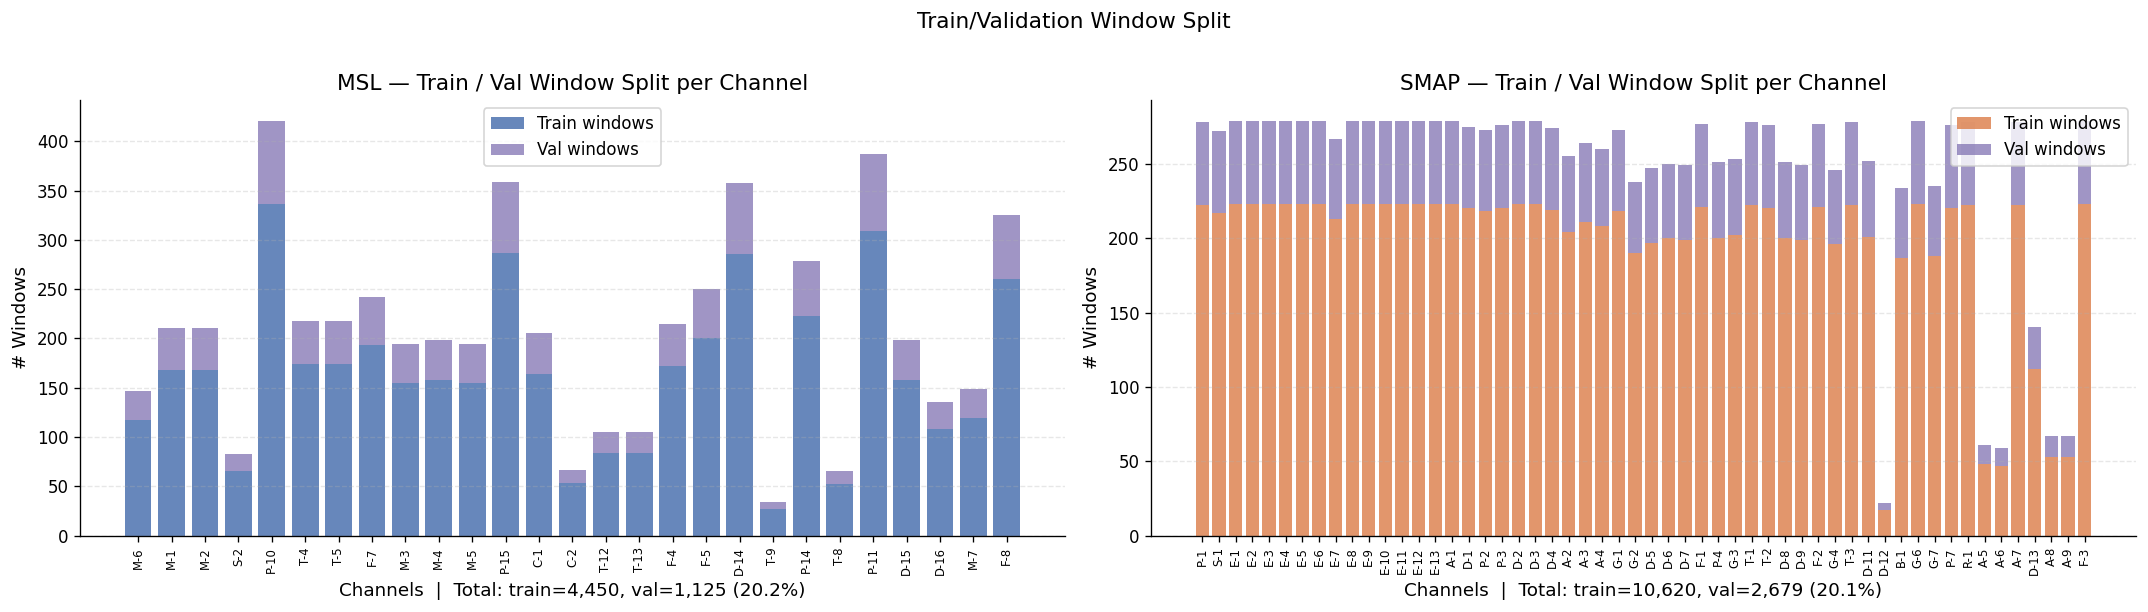

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, win_dict, name, color in zip(axes,
        [msl_windows, smap_windows], ['MSL', 'SMAP'],
        [PALETTE['MSL'], PALETTE['SMAP']]):
    chans  = list(win_dict.keys())
    trains = [win_dict[c]['train'].shape[0] for c in chans]
    vals   = [win_dict[c]['val'].shape[0]   for c in chans]
    x      = np.arange(len(chans))

    ax.bar(x, trains,          color=color,            alpha=0.85, label='Train windows')
    ax.bar(x, vals, bottom=trains, color=PALETTE['val'], alpha=0.75,  label='Val windows')
    ax.set_title(f"{name} — Train / Val Window Split per Channel")
    ax.set_xticks(x); ax.set_xticklabels(chans, rotation=90, fontsize=7)
    ax.set_ylabel("# Windows")
    ax.legend(); ax.grid(axis='y')

    # Annotate split percentages
    total_tr = sum(trains); total_val = sum(vals)
    pct_val  = 100 * total_val / (total_tr + total_val)
    ax.set_xlabel(f"Channels  |  Total: train={total_tr:,}, val={total_val:,} ({pct_val:.1f}%)")

plt.suptitle("Train/Validation Window Split", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


<a id='23'></a>
## 23. Anomaly Label Generation

In [31]:
def build_point_labels(test_len, seqs):
    lbl = np.zeros(test_len, dtype=np.int8)
    for s, e in seqs: lbl[s:e+1] = 1
    return lbl

def build_window_labels(point_lbl, window_size=WINDOW_SIZE, stride=STRIDE_TEST):
    """A window is anomalous if ANY timestep in it is anomalous."""
    indices = range(0, len(point_lbl) - window_size + 1, stride)
    return np.array([int(point_lbl[i:i+window_size].any()) for i in indices], dtype=np.int8)

def build_test_labels(label_df, test_norm_dict):
    pt_lbl, win_lbl = {}, {}
    for _, row in label_df.iterrows():
        chan = row['chan_id']
        if chan not in test_norm_dict: continue
        seqs = parse_seqs(row['anomaly_sequences'])
        pl   = build_point_labels(test_norm_dict[chan].shape[0], seqs)
        wl   = build_window_labels(pl)
        pt_lbl[chan]  = pl
        win_lbl[chan] = wl
    return pt_lbl, win_lbl

msl_pt_lbl,  msl_win_lbl  = build_test_labels(msl_labels,  msl_test_norm)
smap_pt_lbl, smap_win_lbl = build_test_labels(smap_labels, smap_test_norm)

# Label consistency check
def anom_rate(d): return 100 * np.concatenate(list(d.values())).mean()
print(f"MSL  test point-level anomaly rate:  {anom_rate(msl_pt_lbl):.2f}%")
print(f"MSL  test window-level anomaly rate: {anom_rate(msl_win_lbl):.2f}%")
print(f"SMAP test point-level anomaly rate:  {anom_rate(smap_pt_lbl):.2f}%")
print(f"SMAP test window-level anomaly rate: {anom_rate(smap_win_lbl):.2f}%")


MSL  test point-level anomaly rate:  10.53%
MSL  test window-level anomaly rate: 15.19%
SMAP test point-level anomaly rate:  12.81%
SMAP test window-level anomaly rate: 14.26%


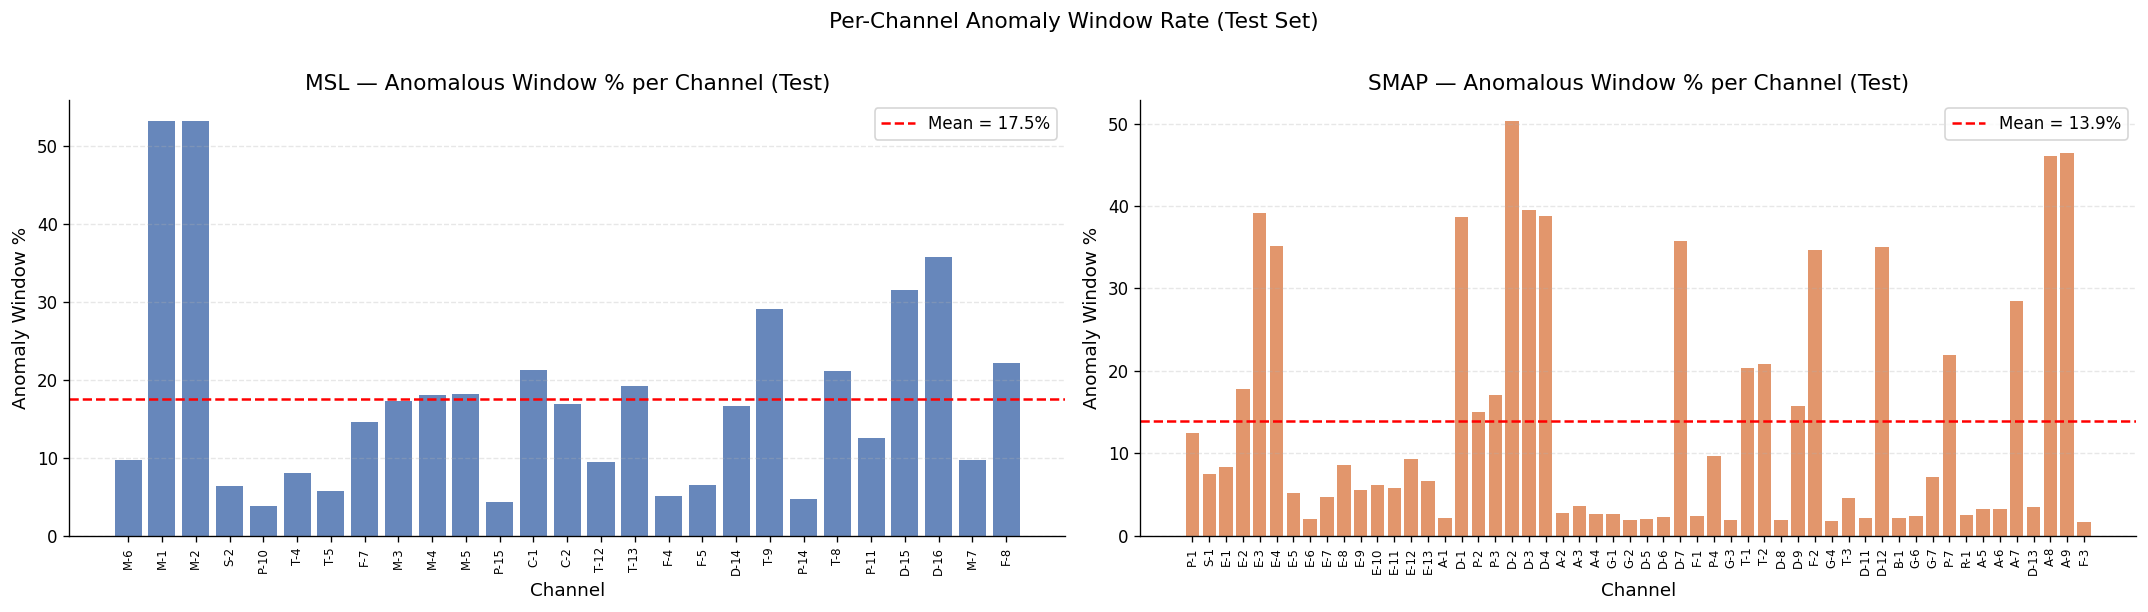

In [32]:
# Visualize label distribution per channel
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, wl, name, color in zip(axes,
        [msl_win_lbl, smap_win_lbl], ['MSL', 'SMAP'],
        [PALETTE['MSL'], PALETTE['SMAP']]):
    ratios = [100 * wl[c].mean() for c in wl]
    chans  = list(wl.keys())
    bars   = ax.bar(chans, ratios, color=color, alpha=0.85, edgecolor='none')
    ax.axhline(np.mean(ratios), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {np.mean(ratios):.1f}%')
    ax.set_title(f"{name} — Anomalous Window % per Channel (Test)")
    ax.set_xlabel("Channel"); ax.set_ylabel("Anomaly Window %")
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.legend(); ax.grid(axis='y')

plt.suptitle("Per-Channel Anomaly Window Rate (Test Set)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


<a id='24'></a>
## 24. Final Preprocessing Summary

In [33]:
total = lambda d, k: sum(v[k].shape[0] for v in d.values())

summary_table = pd.DataFrame({
    'Parameter / Decision'  : [
        'Window size',
        'Stride (train & test)',
        'Normalization method',
        'Scaler fitted on',
        'Val split',
        'Label rule',
        'Evaluation strategy',
        'MSL train windows',
        'MSL val windows',
        'MSL test windows',
        'SMAP train windows',
        'SMAP val windows',
        'SMAP test windows',
        'MSL channels',
        'SMAP channels',
    ],
    'Value / Justification' : [
        f'{WINDOW_SIZE} — ACF decay, anomaly duration CDF, MEMTO paper',
        f'{STRIDE_TRAIN} — prevents MemoryError; evaluation unaffected (point-adjust)',
        'MinMaxScaler [0, 1] — distribution-agnostic, bounded, stable gradients',
        'Train data only — prevents data leakage into test evaluation',
        f'{int(VAL_RATIO*100)}% of train windows (chronological split, not random)',
        'Any-point rule: window labeled anomalous if any timestep is anomalous',
        'Point-adjust F1: any flagged window → entire anomaly sequence credited',
        f'{total(msl_windows, "train"):,}',
        f'{total(msl_windows, "val"):,}',
        f'{total(msl_windows, "test"):,}',
        f'{total(smap_windows, "train"):,}',
        f'{total(smap_windows, "val"):,}',
        f'{total(smap_windows, "test"):,}',
        f'{len(msl_windows)}',
        f'{len(smap_windows)}',
    ],
})
display(summary_table)

print()
print("=" * 65)
print("  ✅  DATA READY FOR MEMTO TRAINING")
print("=" * 65)


,Parameter / Decision,Value / Justification
0,Window size,"100 — ACF decay, anomaly duration CDF, MEMTO p..."
1,Stride (train & test),10 — prevents MemoryError; evaluation unaffect...
2,Normalization method,"MinMaxScaler [0, 1] — distribution-agnostic, b..."
3,Scaler fitted on,Train data only — prevents data leakage into t...
4,Val split,"20% of train windows (chronological split, not..."
5,Label rule,Any-point rule: window labeled anomalous if an...
6,Evaluation strategy,Point-adjust F1: any flagged window → entire a...
7,MSL train windows,"4,450"
8,MSL val windows,"1,125"
9,MSL test windows,"7,117"



  ✅  DATA READY FOR MEMTO TRAINING


<a id='25'></a>
## 25. Save Preprocessed Data

In [34]:
SAVE_DIR = "./preprocessed"
os.makedirs(SAVE_DIR, exist_ok=True)

saved_count = 0
for ds_name, win_dict, pt_lbl, win_lbl in [
        ("MSL",  msl_windows,  msl_pt_lbl,  msl_win_lbl),
        ("SMAP", smap_windows, smap_pt_lbl, smap_win_lbl)]:

    ds_dir = os.path.join(SAVE_DIR, ds_name)
    os.makedirs(ds_dir, exist_ok=True)

    for chan, splits in win_dict.items():
        cd = os.path.join(ds_dir, chan)
        os.makedirs(cd, exist_ok=True)
        np.save(os.path.join(cd, "train.npy"),        splits['train'])
        np.save(os.path.join(cd, "val.npy"),           splits['val'])
        np.save(os.path.join(cd, "test.npy"),          splits['test'])
        if chan in win_lbl:
            np.save(os.path.join(cd, "test_labels_window.npy"), win_lbl[chan])
        if chan in pt_lbl:
            np.save(os.path.join(cd, "test_labels_point.npy"),  pt_lbl[chan])
        saved_count += 1

print(f"✅ Saved {saved_count} channels to: {SAVE_DIR}/")
print()
print("Directory structure:")
print("  preprocessed/")
print("  ├── MSL/")
print("  │   └── <chan_id>/")
print("  │       ├── train.npy              shape: (N_train, 100, F)")
print("  │       ├── val.npy                shape: (N_val,   100, F)")
print("  │       ├── test.npy               shape: (N_test,  100, F)")
print("  │       ├── test_labels_window.npy shape: (N_test,)")
print("  │       └── test_labels_point.npy  shape: (T_test,)")
print("  └── SMAP/ (same structure)")


✅ Saved 81 channels to: ./preprocessed/

Directory structure:
  preprocessed/
  ├── MSL/
  │   └── <chan_id>/
  │       ├── train.npy              shape: (N_train, 100, F)
  │       ├── val.npy                shape: (N_val,   100, F)
  │       ├── test.npy               shape: (N_test,  100, F)
  │       ├── test_labels_window.npy shape: (N_test,)
  │       └── test_labels_point.npy  shape: (T_test,)
  └── SMAP/ (same structure)
